In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

In [2]:
crash_colors = ["#044FB9", "#C8102E", "#54585A", "#FF8200", "#00B2A9"]
sns.set_palette(sns.color_palette(crash_colors))
sns.set_style("whitegrid", {'axes.spines.left': False, 'axes.spines.right': False, 'axes.spines.top': False})

In [3]:
data = pd.read_csv('../data/interim/Crash_Reporting_-_Drivers_Data_cleaned.csv')
df = data.copy()

In [5]:
df = df[sorted(df.columns)]

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207766 entries, 0 to 207765
Data columns (total 61 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   ACRS Report Type                     207766 non-null  object 
 1   Agency Name                          207766 non-null  object 
 2   Collision Type                       207766 non-null  object 
 3   Collision Type Clean                 207766 non-null  object 
 4   Crash Dayofweek                      207766 non-null  int64  
 5   Crash Dayofweek Clean                207766 non-null  object 
 6   Crash Hour                           207766 non-null  int64  
 7   Crash Location Type                  207766 non-null  object 
 8   Crash Month                          207766 non-null  int64  
 9   Crash Month Clean                    207766 non-null  object 
 10  Crash Season Clean                   207766 non-null  object 
 11  Cross Road Ca

In [7]:
def get_feature_insights(target="Injury Severity", feature="Driver At Fault", explanation="Nil"):
    # Define a consistent "Safety Palette" for the Target
    # Mapping specific severities to specific colors ensures 'Fatal' is always Red
    def get_color(col_name):
            c = col_name.upper()
            if "FATAL" in c: return '#C8102E'          # Emergency Red
            if "SERIOUS" in c: return '#FF8200'        # Caution Orange
            if "POSSIBLE" in c: return '#FFD700'       # Warning Yellow
            if "MINOR" in c: return '#1B365D'          # Police Blue
            if "NO APPARENT" in c: return '#54585A'    # Asphalt Gray
            return '#808080'
    
    # --- PART 1: FEATURE DISTRIBUTION (Your Original Logic) ---
    num_unique = df[feature].nunique()
    
    if num_unique > 4:
        plt.figure(figsize=(10, 5))
        perc = df[feature].value_counts(normalize=True) * 100
        ax = sns.barplot(x=perc.index, y=perc.values, color='#1B365D') # Uniform professional blue
        plt.title(f"FIELD REPORT: {feature.upper()} DISTRIBUTION", fontweight='bold', loc='left')
        plt.ylabel("Percentage (%)")
        plt.xticks(rotation=45)
    else:
        plt.figure(figsize=(7, 7))
        counts = df[feature].value_counts()
        plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, 
                colors=sns.color_palette("Blues_d", n_colors=num_unique),
                wedgeprops={'edgecolor': 'white', 'linewidth': 2})
        # Donut hole for modern look
        plt.gca().add_artist(plt.Circle((0,0), 0.70, fc='white'))
        plt.title(f"FIELD REPORT: {feature.upper()} ANALYSIS", fontweight='bold')
    
    plt.tight_layout()
    plt.show()

    print("\n" + "—"*60) 

    # --- PART 2: THE "VISIBLE FATALITY" CROSSTAB ---
   # PART 2: THE UPDATED PLOT
    ct = pd.crosstab(df[feature], df[target], normalize="index") * 100
    
    # Assign colors dynamically based on the column name content
    current_palette = [get_color(col) for col in ct.columns]
    
    ax = ct.plot(kind="bar", figsize=(12, 6), width=0.8, color=current_palette)
    
    plt.yscale('log')
    ax.yaxis.set_major_formatter(mtick.ScalarFormatter())
    
    # Add labels so the tiny Fatal percentages are readable
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height:.2f}%', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='bottom', fontsize=8, fontweight='bold',
                        xytext=(0, 5), textcoords='offset points')

    plt.title(f"CRITICAL IMPACT: {target} by {feature}", fontweight='bold', loc='left')
    plt.ylabel("Percentage (Log Scale %)")
    plt.xticks(rotation=45)
    plt.legend(title="Severity Level", bbox_to_anchor=(1, 1))
    sns.despine()
    plt.show()

    print("\n" + "—"*60)
    print(f"\nANALYST INSIGHTS:\n\n{explanation}\n")

## Driver Related Factors

In [8]:
driver_cols = [
    "Driver At Fault",
    "Driver Substance Abuse Clean",
    "Driver Distracted By Clean",
    "Drivers License State clean",
    "Driverless Vehicle"
]

driver_factor_explanations = {

    "Driver At Fault":
    """At-fault drivers have a higher percentage of fatal and serious injuries than those who are not at fault. 
    Cases of unknown fault have abnormally high fatal rates, which are probably a result of underreporting. In general, driver 
    responsibility is a good behavioral indicator of crash severity.""",

    
    "Driver Substance Abuse Clean":
    """Crash severity is greatly affected by substance abuse. The severity of fatal injuries is highest in the case of alcohol and drug use together, 
    followed by drug and medication use. The lowest levels of crash severity are associated with crashes that involve no substance abuse.""",


    "Driver Distracted By Clean":
    """Distracted driving is a strong predictor of the severity of injury. The percentages of fatal and serious injuries are higher in 
    in-vehicle distractions and phone-related distractions. The severity of injury is lower in the absence of distraction, 
    which emphasizes distraction as a prominent behavioral risk factor.""",


    "Drivers License State clean":
    """The injury severity for drivers from outside the local state is slightly higher, perhaps because of unfamiliarity with the road conditions. 
    The impact of license state is relatively weaker than behavioral factors like substance abuse and distraction.""",


    "Driverless Vehicle":
    """Involvement of self-driving vehicles is a very rare event in the data and has little effect on the patterns of injury severity.
    The majority of the unknown cases are probably due to underreporting and not actual involvement of self-driving vehicles."""
}

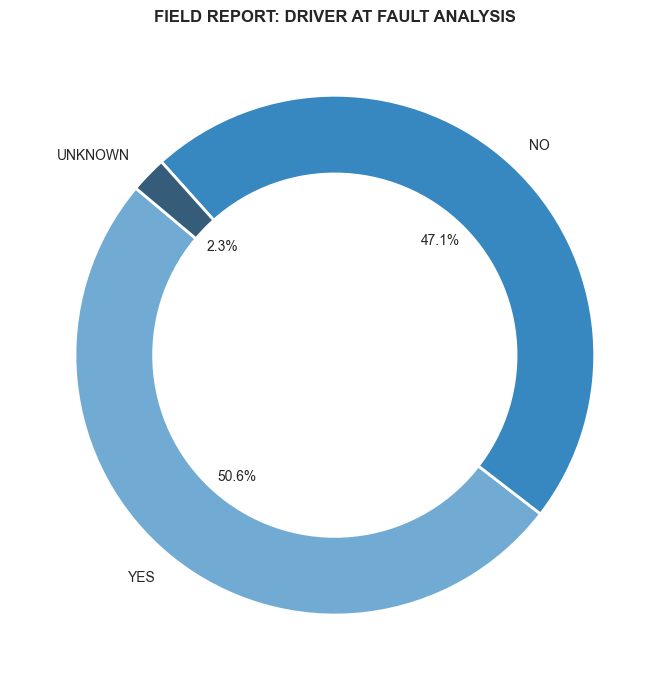


————————————————————————————————————————————————————————————


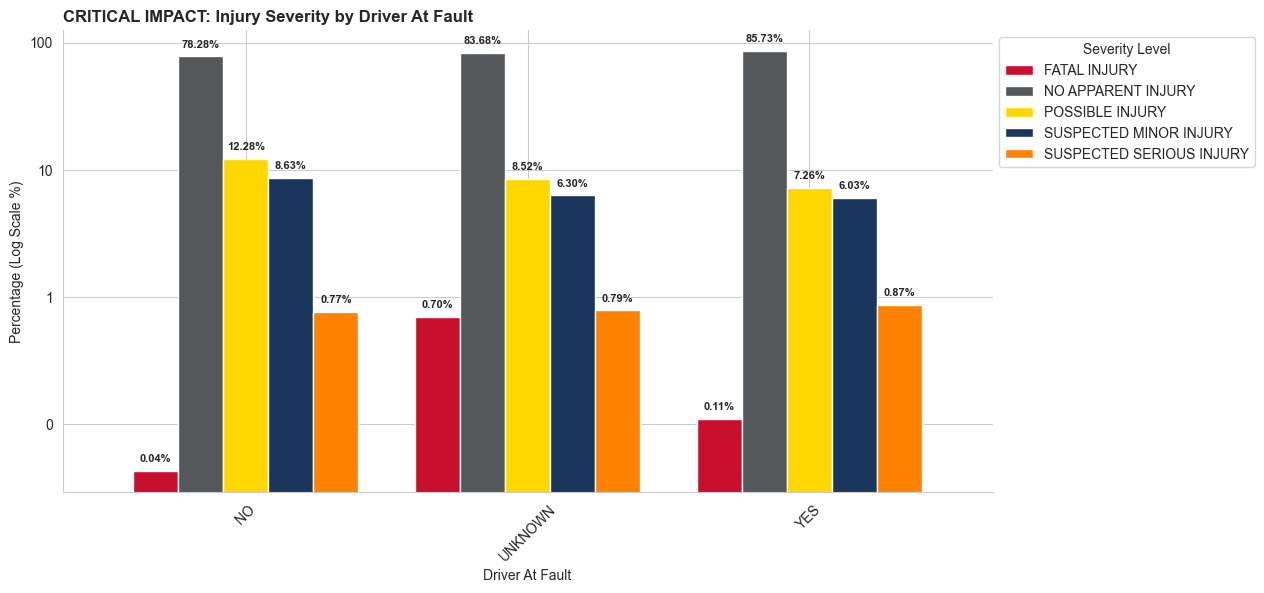


————————————————————————————————————————————————————————————

ANALYST INSIGHTS:

At-fault drivers have a higher percentage of fatal and serious injuries than those who are not at fault. 
    Cases of unknown fault have abnormally high fatal rates, which are probably a result of underreporting. In general, driver 
    responsibility is a good behavioral indicator of crash severity.



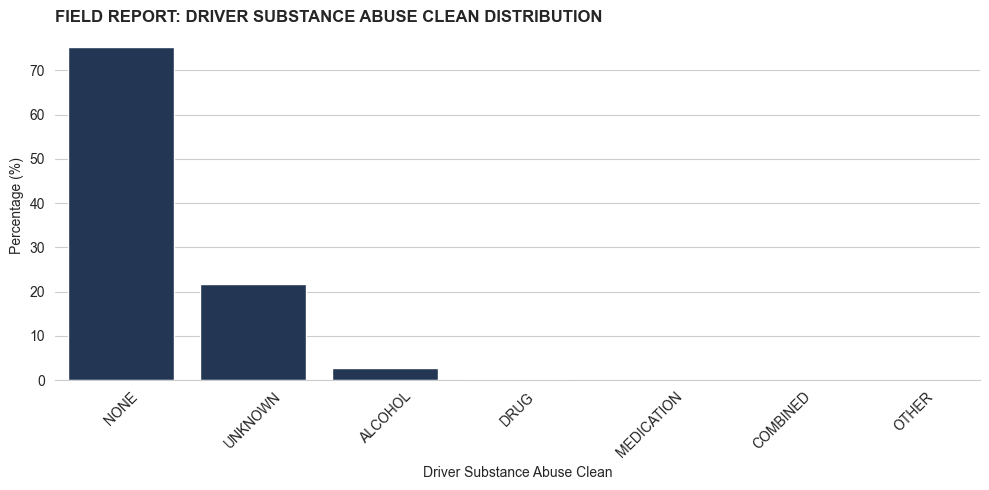


————————————————————————————————————————————————————————————


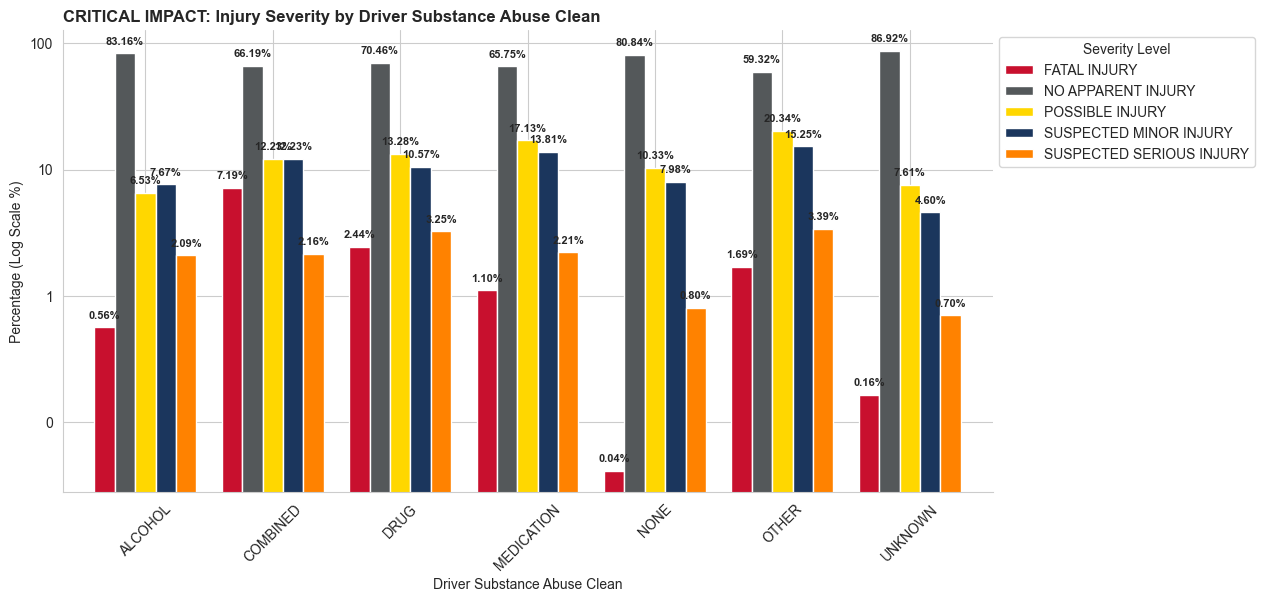


————————————————————————————————————————————————————————————

ANALYST INSIGHTS:

Crash severity is greatly affected by substance abuse. The severity of fatal injuries is highest in the case of alcohol and drug use together, 
    followed by drug and medication use. The lowest levels of crash severity are associated with crashes that involve no substance abuse.



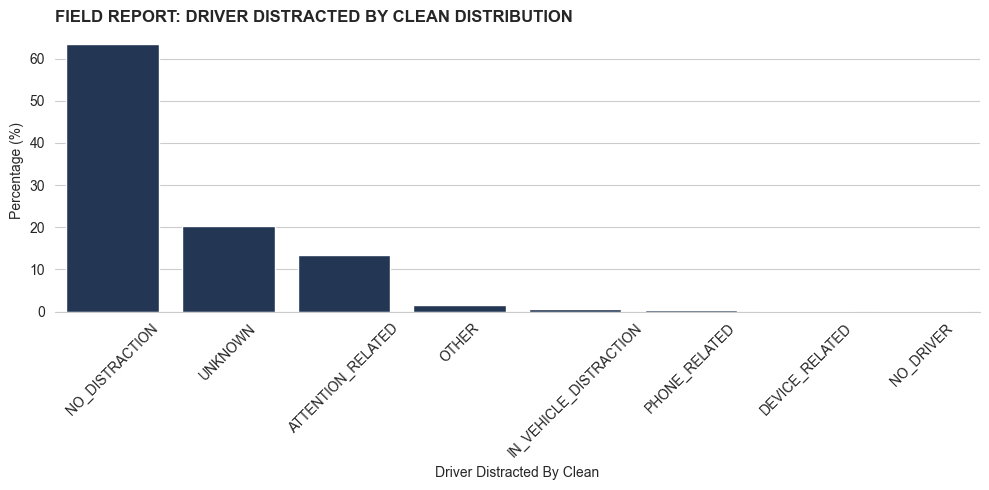


————————————————————————————————————————————————————————————


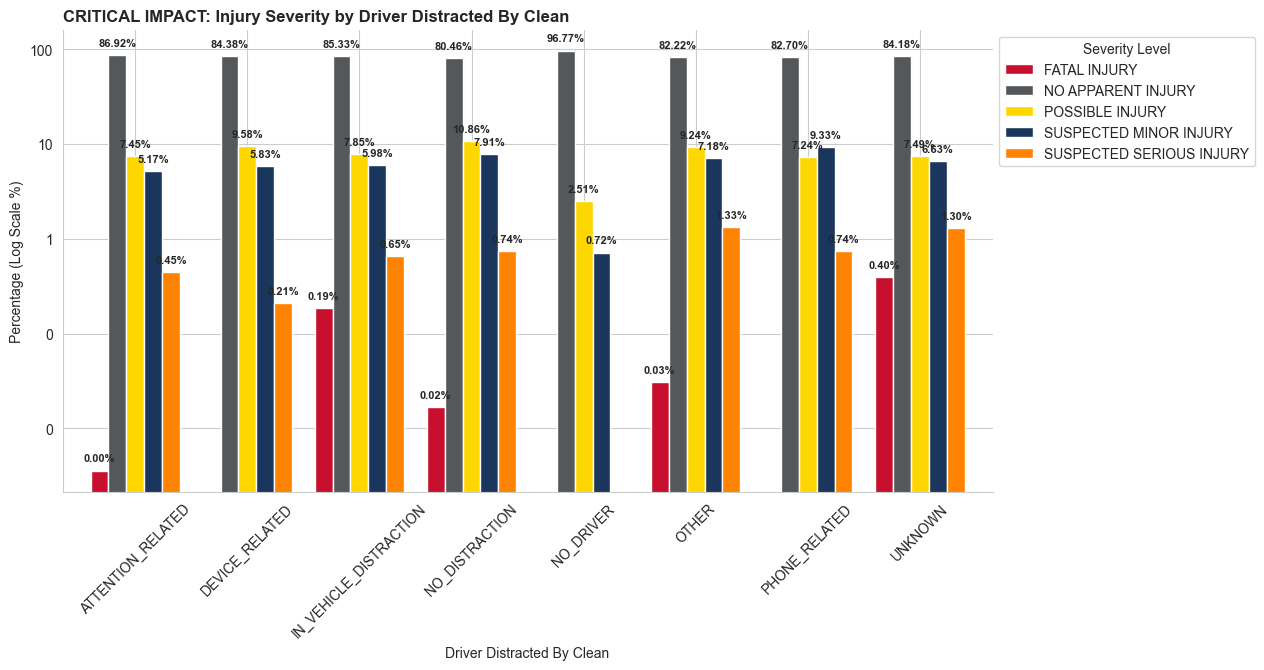


————————————————————————————————————————————————————————————

ANALYST INSIGHTS:

Distracted driving is a strong predictor of the severity of injury. The percentages of fatal and serious injuries are higher in 
    in-vehicle distractions and phone-related distractions. The severity of injury is lower in the absence of distraction, 
    which emphasizes distraction as a prominent behavioral risk factor.



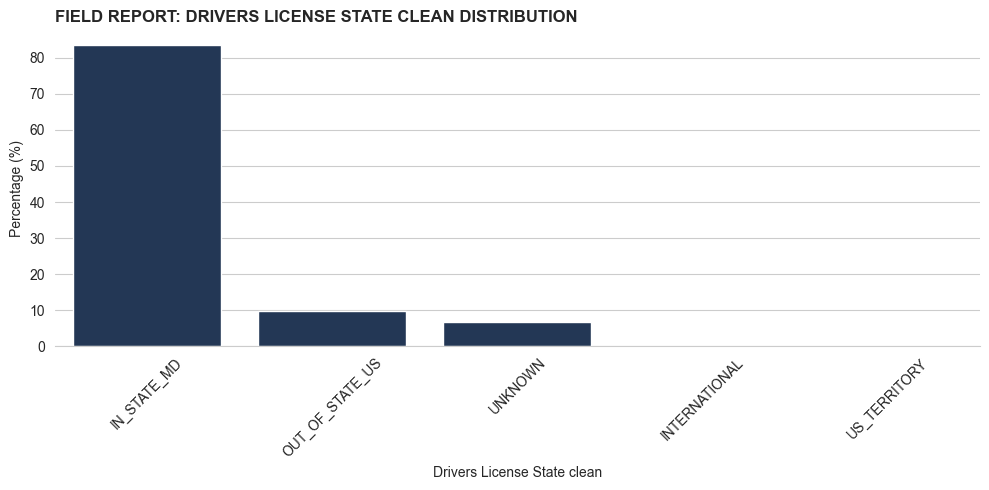


————————————————————————————————————————————————————————————


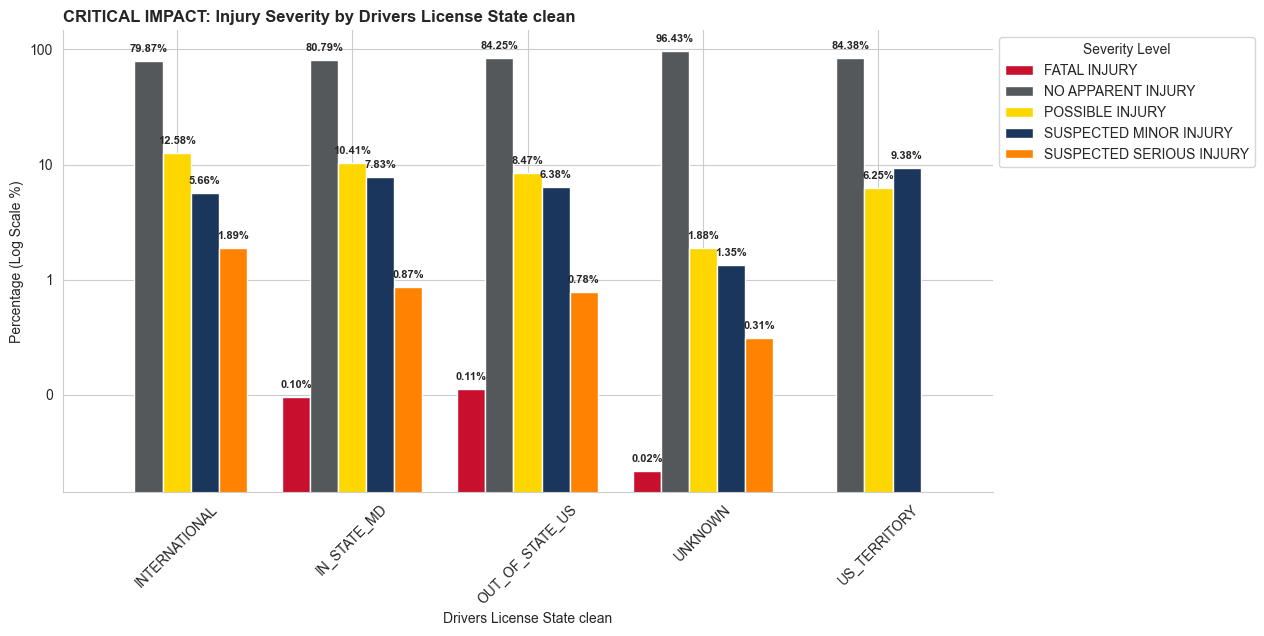


————————————————————————————————————————————————————————————

ANALYST INSIGHTS:

The injury severity for drivers from outside the local state is slightly higher, perhaps because of unfamiliarity with the road conditions. 
    The impact of license state is relatively weaker than behavioral factors like substance abuse and distraction.



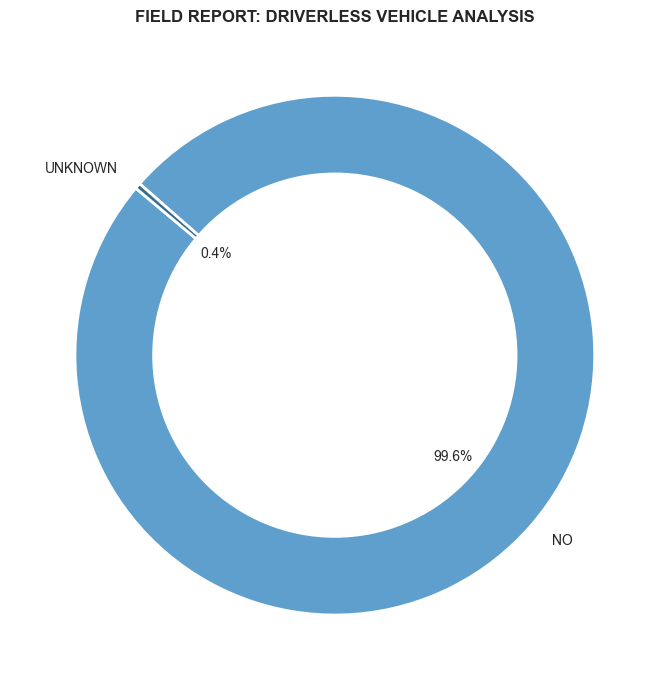


————————————————————————————————————————————————————————————


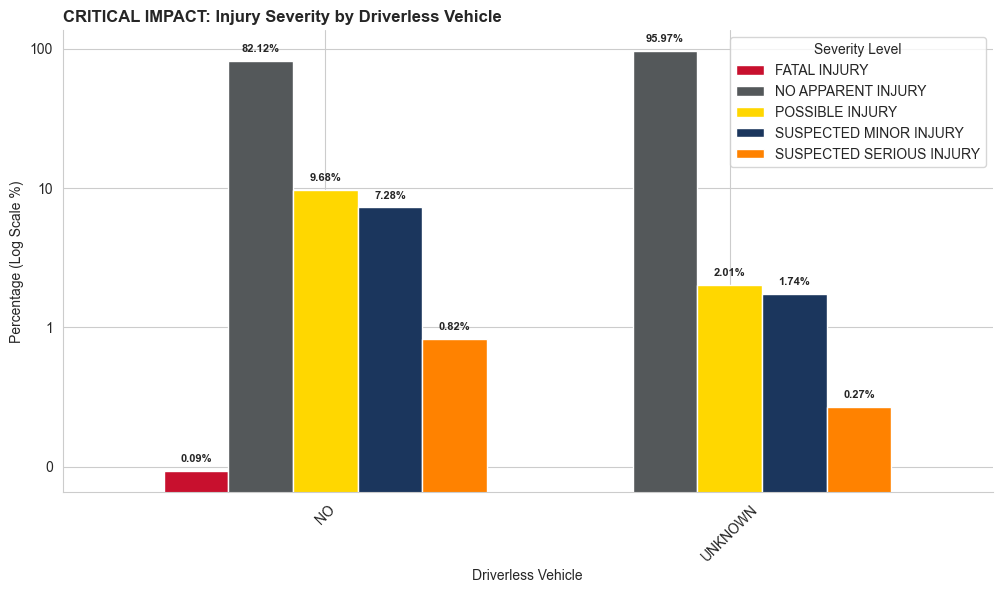


————————————————————————————————————————————————————————————

ANALYST INSIGHTS:

Involvement of self-driving vehicles is a very rare event in the data and has little effect on the patterns of injury severity.
    The majority of the unknown cases are probably due to underreporting and not actual involvement of self-driving vehicles.



In [9]:
for col in driver_cols:
    get_feature_insights(feature=col,explanation=driver_factor_explanations[col])

### Factors such as substance use, distraction, and fault responsibility that influence driver behavior have the most effect on injury severity in the case of road accidents. Substance-impaired driving, especially when multiple substances are involved, has a profound effect on the risk of fatal injury. Distraction, especially in-vehicle cognitive distraction, is also a significant contributor to injury severity. Structural variables such as license state or driverless vehicle have a relatively weak effect.

## Vehicle Related Factors

In [10]:
bins = [0, 10, 20, 30, 40, 50 , np.inf]
labels = ['0-10', '10-20', '20-30', '30-40','40-50', '50+']
df['Vehicle Age Group'] = pd.cut(df['Vehicle Age'], bins=bins, labels=labels, right=True)

In [ ]:
VehicleRelatedFactors = [
    "Vehicle Age Group",
    "Vehicle Body Type Clean",
    "Vehicle Damage Extent Clean",
    "Vehicle First Impact Location Clean",
    "Vehicle Going Dir Clean",
    "Vehicle Movement Clean",
    "Parked Vehicle"
]

vehicle_explanations = {

"Vehicle Age Group":
"""The severity of injuries in a crash rises with the age of the vehicle. Vehicles above 40 years have a significantly higher rate of \n fatal and serious injuries because of the absence of current safety features and outdated safety technology. The rate of no-injury cases \n  \nis higher in newer vehicles (0-20 years), which shows the efficiency of current safety features.""",


"Vehicle Body Type Clean":
"""The severity of injury is largely dependent on the type of vehicle. Two-wheelers have a very high rate of fatal and serious injuries \n due to the lack of physical protection for the rider. Buses and trucks have a very low injury severity rate for their occupants due to \n their size and strength. Passenger cars and SUVs have a moderate risk level.""",


"Vehicle Damage Extent Clean":
"""The severity of injury is directly proportional to the extent of damage. Greater vehicle damage is significantly associated with more \n serious and fatal injuries, which reveals the high-impact nature of the crash. The minor or no damage category is overwhelmingly \n associated with no apparent injury, which validates the extent of damage as a good indicator of the severity of the crash.""",


"Vehicle First Impact Location Clean":
"""The location of the impact has a significant influence on injury severities. Side impacts and rollover crashes have a higher incidence  \nof serious injury and fatalities, while rear impacts are generally less severe, and non-collision scenarios are the safest.""",


"Vehicle Going Dir Clean":
"""The Vehicle direction has very little direct effect on injury severity. The similarity in injury distributions for all directions \n indicates that the dynamics of the crash and the environment are more important than the direction of travel.""",


"Vehicle Movement Clean":
"""Patterns of vehicle movement have a strong effect on the severity of crashes. High-risk behaviors like sudden lane changes or \n aggressive driving are associated with higher injury risks. Reversing and parking activities have the lowest levels of severity because of \n lower speeds. Straight vehicle movement and turning are responsible for moderate injury severity because of higher speeds.""",


"Parked Vehicle":
"""Crashes involving parked cars display a very low level of injury severity since these types of accidents happen at low speeds. \n Collisions involving moving vehicles display a significantly higher level of injury risk."""

}

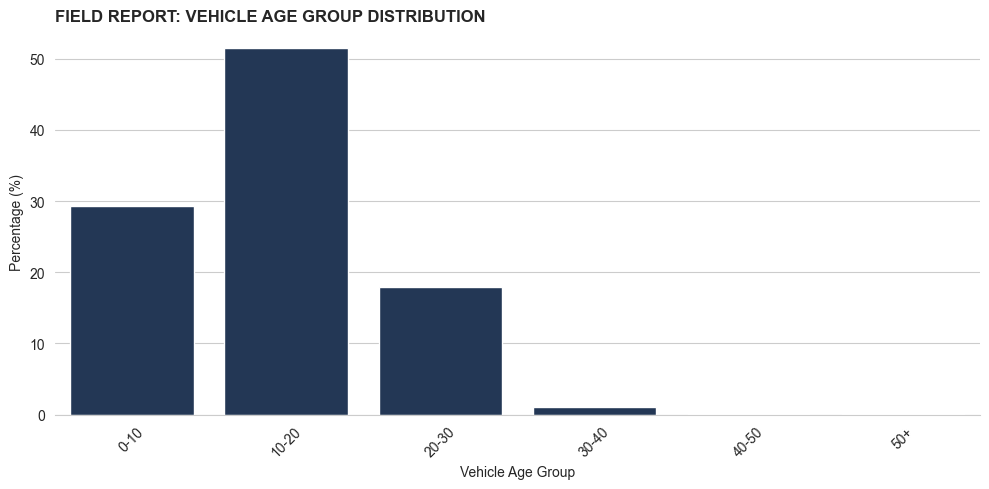


————————————————————————————————————————————————————————————


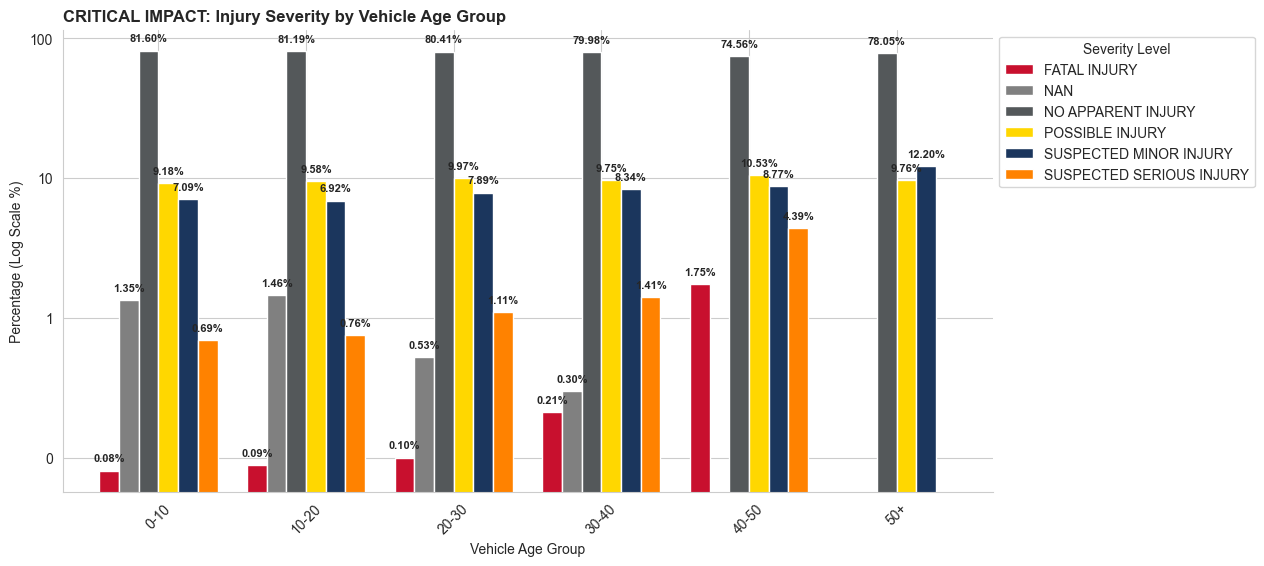


————————————————————————————————————————————————————————————

ANALYST INSIGHTS:

The severity of injuries in a crash rises with the age of the vehicle. Vehicles above 40 years have a significantly higher rate of 
 fatal and serious injuries because of the absence of current safety features and outdated safety technology. The rate of no-injury cases 
  
is higher in newer vehicles (0-20 years), which shows the efficiency of current safety features.



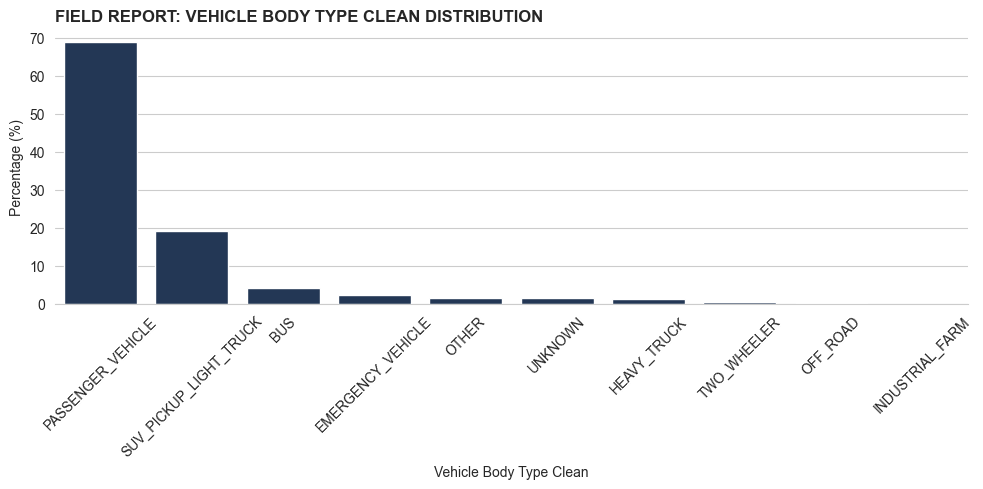


————————————————————————————————————————————————————————————


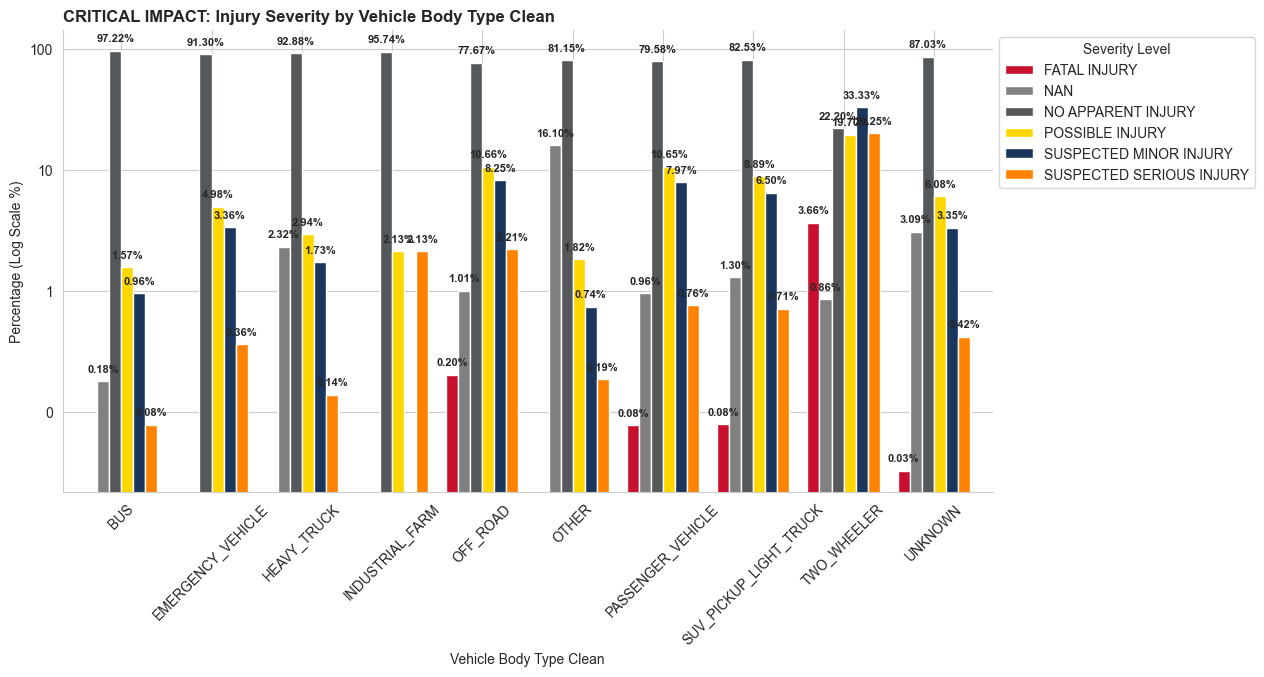


————————————————————————————————————————————————————————————

ANALYST INSIGHTS:

The severity of injury is largely dependent on the type of vehicle. Two-wheelers have a very high rate of fatal and serious injuries 
 due to the lack of physical protection for the rider. Buses and trucks have a very low injury severity rate for their occupants due to 
 their size and strength. Passenger cars and SUVs have a moderate risk level.



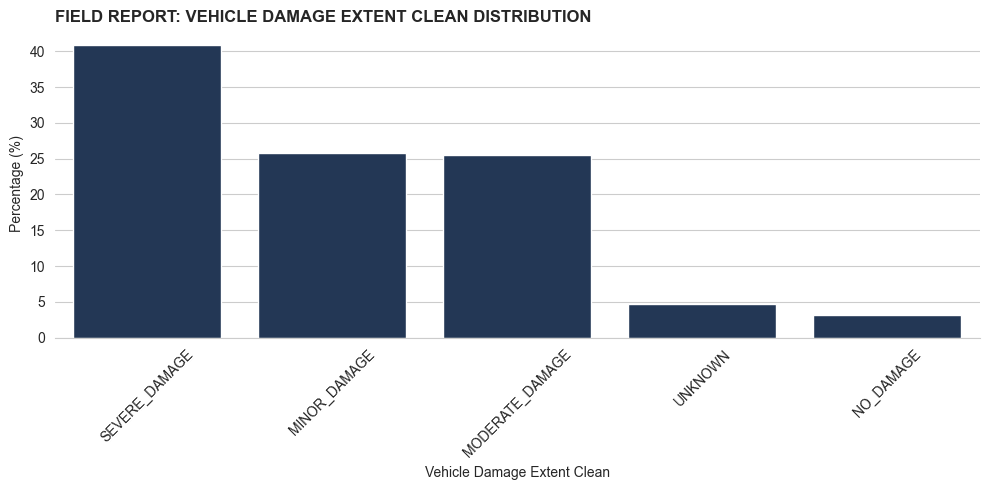


————————————————————————————————————————————————————————————


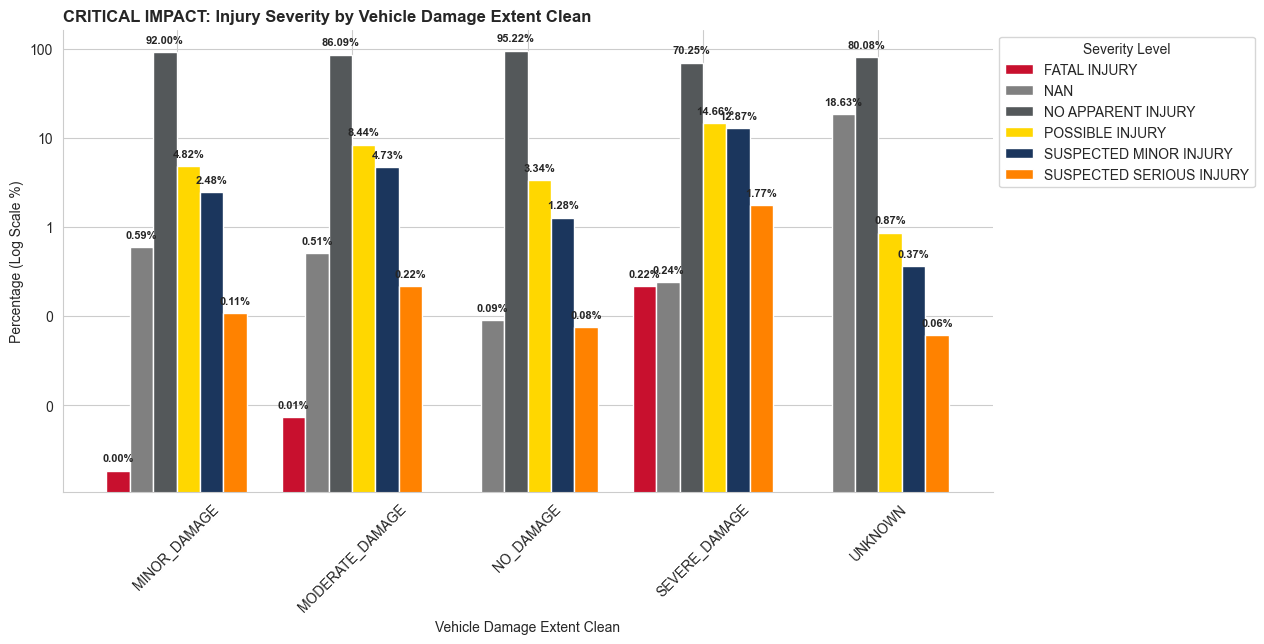


————————————————————————————————————————————————————————————

ANALYST INSIGHTS:

The severity of injury is directly proportional to the extent of damage. Greater vehicle damage is significantly associated with more 
 serious and fatal injuries, which reveals the high-impact nature of the crash. The minor or no damage category is overwhelmingly 
 associated with no apparent injury, which validates the extent of damage as a good indicator of the severity of the crash.



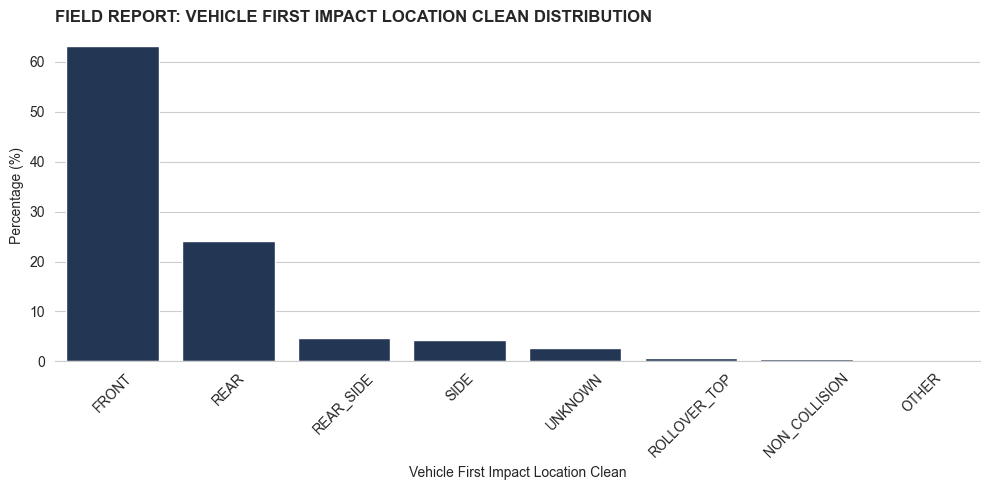


————————————————————————————————————————————————————————————


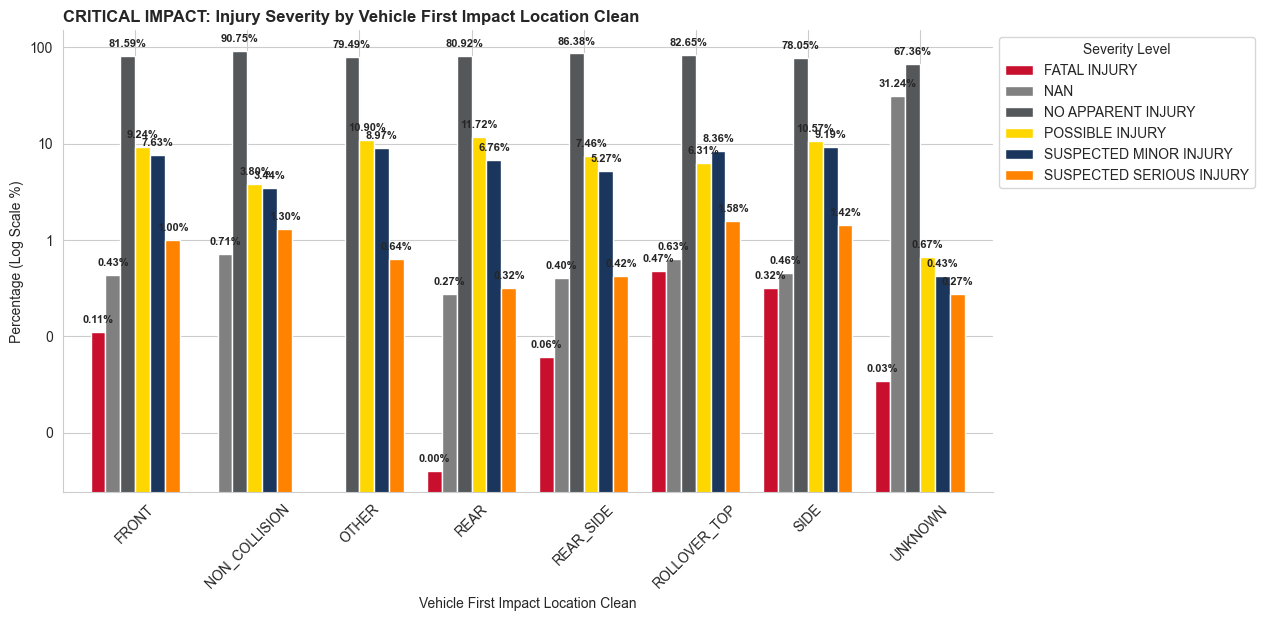


————————————————————————————————————————————————————————————

ANALYST INSIGHTS:

The location of the impact has a significant influence on injury severities. Side impacts and rollover crashes have a higher incidence  
of serious injury and fatalities, while rear impacts are generally less severe, and non-collision scenarios are the safest.



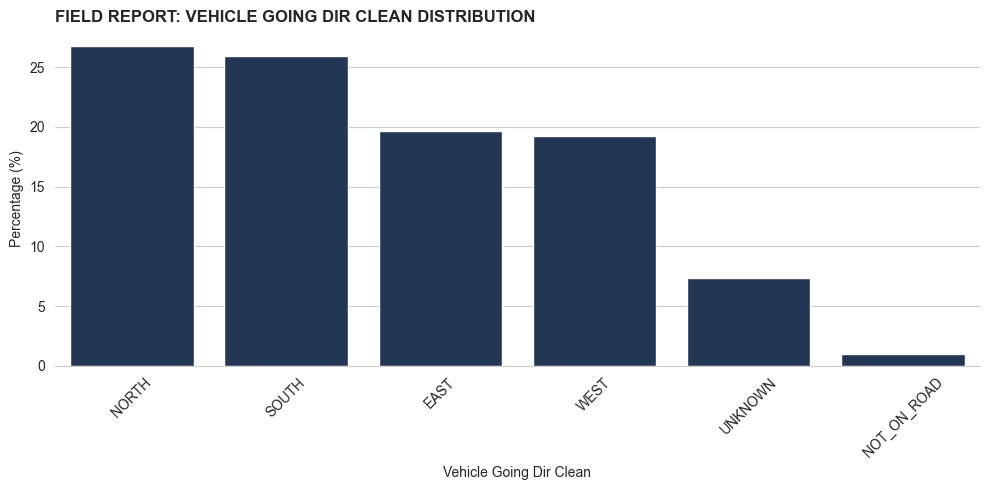


————————————————————————————————————————————————————————————


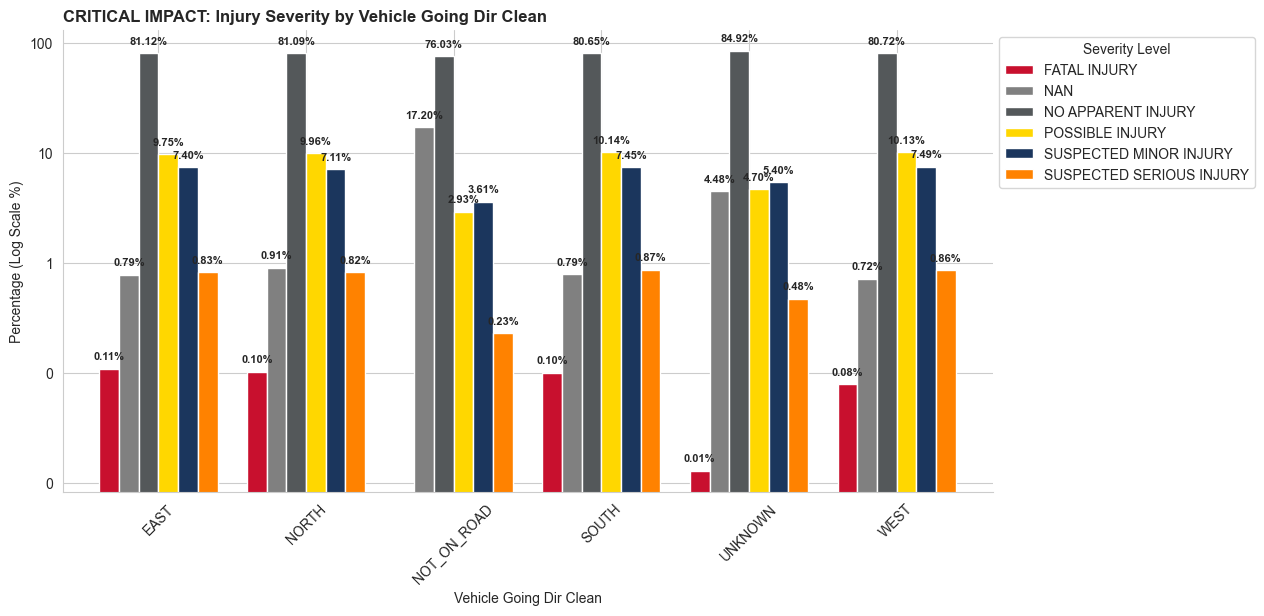


————————————————————————————————————————————————————————————

ANALYST INSIGHTS:

The Vehicle direction has very little direct effect on injury severity. The similarity in injury distributions for all directions 
 indicates that the dynamics of the crash and the environment are more important than the direction of travel.



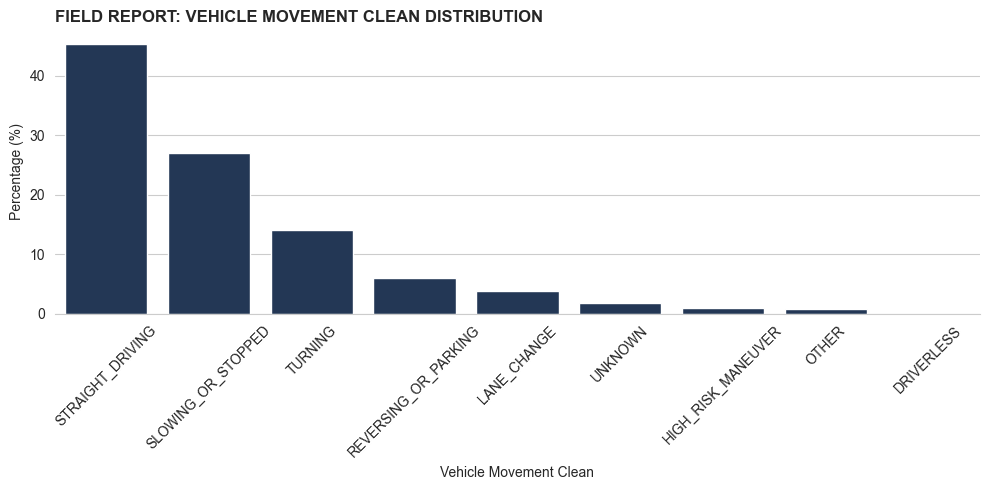


————————————————————————————————————————————————————————————


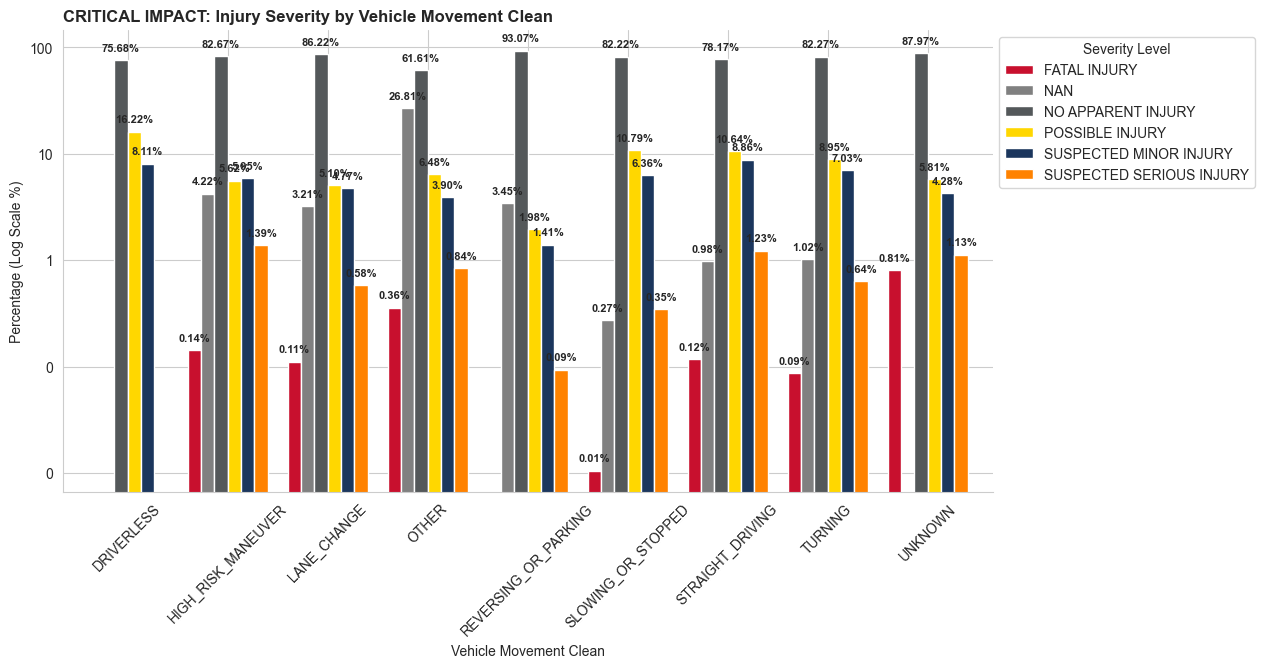


————————————————————————————————————————————————————————————

ANALYST INSIGHTS:

Patterns of vehicle movement have a strong effect on the severity of crashes. High-risk behaviors like sudden lane changes or 
 aggressive driving are associated with higher injury risks. Reversing and parking activities have the lowest levels of severity because of 
 lower speeds. Straight vehicle movement and turning are responsible for moderate injury severity because of higher speeds.



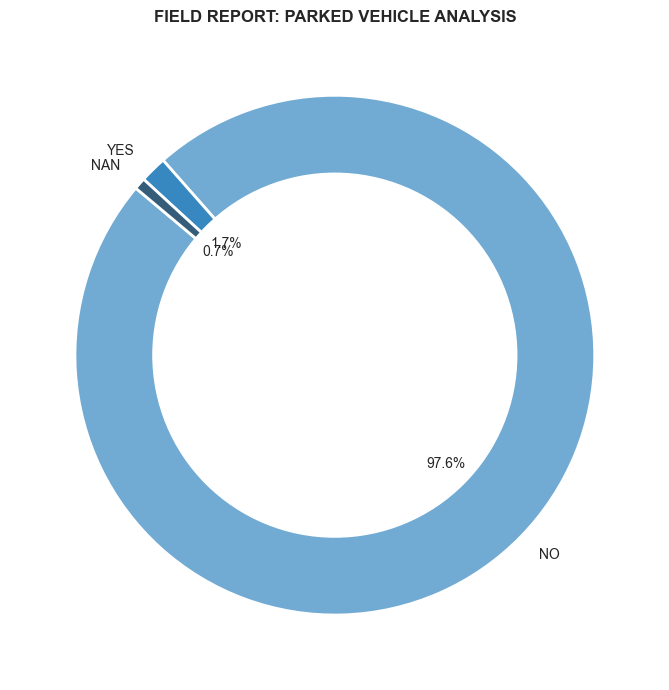


————————————————————————————————————————————————————————————


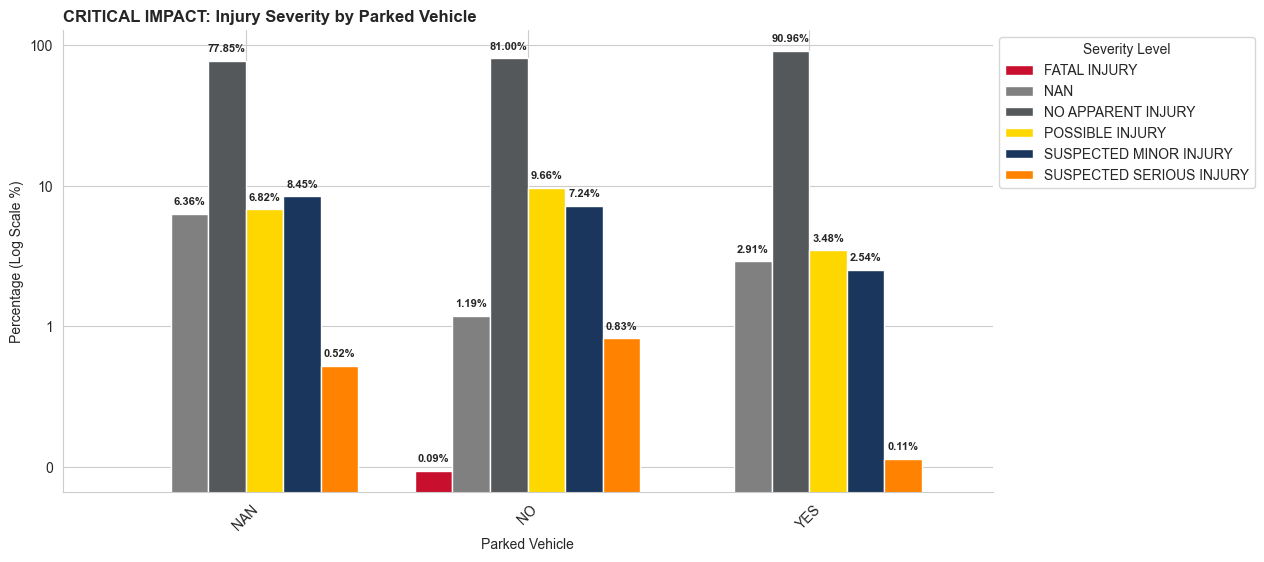


————————————————————————————————————————————————————————————

ANALYST INSIGHTS:

Crashes involving parked cars display a very low level of injury severity since these types of accidents happen at low speeds. 
 Collisions involving moving vehicles display a significantly higher level of injury risk.



In [ ]:
for col in VehicleRelatedFactors :
    get_feature_insights(feature=col , explanation=vehicle_explanations[col])


##### - Analysis of the vehicle-related factors shows that the severity of injury in road accidents is significantly affected by the characteristics of the vehicle, the nature of the accident, and the conditions of movement. 
##### - Older vehicles have a higher rate of fatal and serious injuries, mainly because of the lack of advanced safety features and the deterioration of the vehicle’s condition, while newer vehicles have better outcomes in terms of safety. 
##### - The type of vehicle plays a very important role in the severity of injury, with two-wheelers having the highest proportion of fatal and serious injuries because of the lack of physical protection, while bigger vehicles such as buses and trucks have lower injury severity because of their strength.
##### - Crash severity is also strongly related to the level of vehicle damage, as more severe damage is associated with much higher levels of injury, which reflect the severity of the impact. 
##### - In addition, the location of the impact is a significant factor, as side impacts and rollovers are the most severe, as they result in greater vulnerability to injury, while rear impacts and non-collision are likely to be less severe. 
##### - The movement patterns also show that high-risk driving and high-speed driving conditions are associated with higher injury severity, while reversing, parking, and collisions with parked vehicles are likely to be minor or no injuries, as they occur at lower speeds. 
##### - In general, the results indicate that vehicle safety design, crash impact dynamics, and driving conditions are important factors that determine the outcome of accident injuries, making them highly significant factors in road safety analysis and injury severity modeling.

## Road Related Factors

In [ ]:
bins = [0, 10, 20, 30, 40, 50 , np.inf]
labels = ['0-10', '10-20', '20-30', '30-40','40-50', '50+']
df['Speed Limit Group'] = pd.cut(df['Speed Limit'], bins=bins, labels=labels, right=True)

In [ ]:
Road_related_factors = [
    "Route Type Clean",
    "Cross Road Category Clean",
    "Road Category Clean",
    "Off-Road Description Clean",
    "Traffic Control Clean",
    "Surface Condition Clean",
    "Speed Limit Group",
]

road_factor_insights = {
"Route Type Clean":
"Patterns of crash severity are similar for all route types, although slightly higher proportions of possible and serious injuries occur \n on highways and main roads compared with local roads. This indicates that higher speeds and volumes on highways and main roads increase \n the risk of injury, while local roads have lower severity outcomes.",

"Cross Road Category Clean":
"High-speed and ramp intersections have relatively higher proportions of injuries than arterial and local cross roads, which shows that \n   the merging conflicts, turning movements, and speed differences at these points tend to increase the severity of the crash.",

"Road Category Clean":
"The High speed roads always demonstrate higher possible and serious injury percentages than local or arterial roads. This further \n supports the strong relationship between road hierarchy, travel speed, and injury severity.",

"Off-Road Description Clean":
"Off-road areas like parking lots, alleys, and driveways have a remarkably low level of injury severity. This is mainly because   there \n are lower speeds and fewer traffic conflicts in these areas",

"Traffic Control Clean":
"Areas that lack traffic control or have complex signal systems are likely to have a higher proportion of injuries than controlled \n areas.   Stop signs, signals, and directed traffic are traffic control devices that can reduce the risk of severe injury by controlling traffic flow.",

"Surface Condition Clean":
"Loose or unstable road surfaces have a significantly higher percentage of minor and serious injuries compared to other road surfaces. \n  Dry and wet road surfaces have similar distributions of severity, suggesting that extreme road conditions are more hazardous than weather \n conditions.",

"Speed Limit Group":
"The severity of injury rises steadily with increasing speed limits. Zones with higher speed limits (particularly above 40 mph) \n demonstrate evident rises in   possible, minor, and serious injuries, proving speed to be a very strong predictor of crash severity."
}



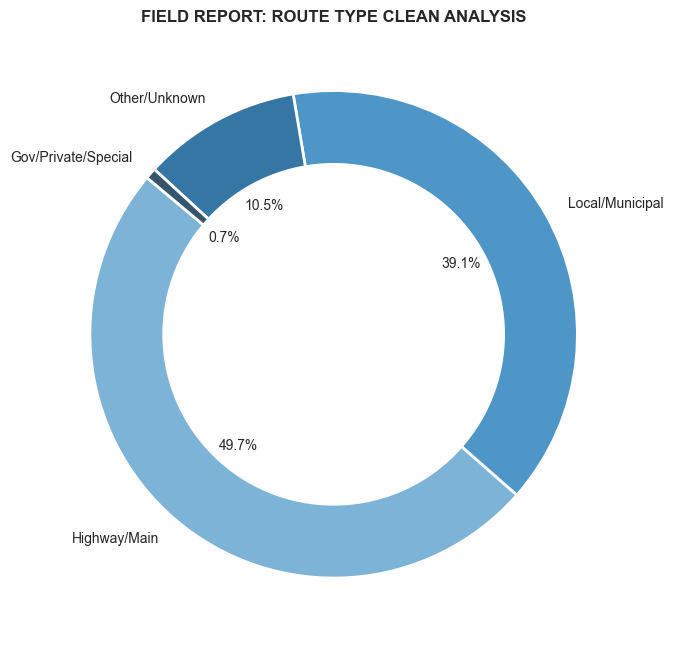


————————————————————————————————————————————————————————————


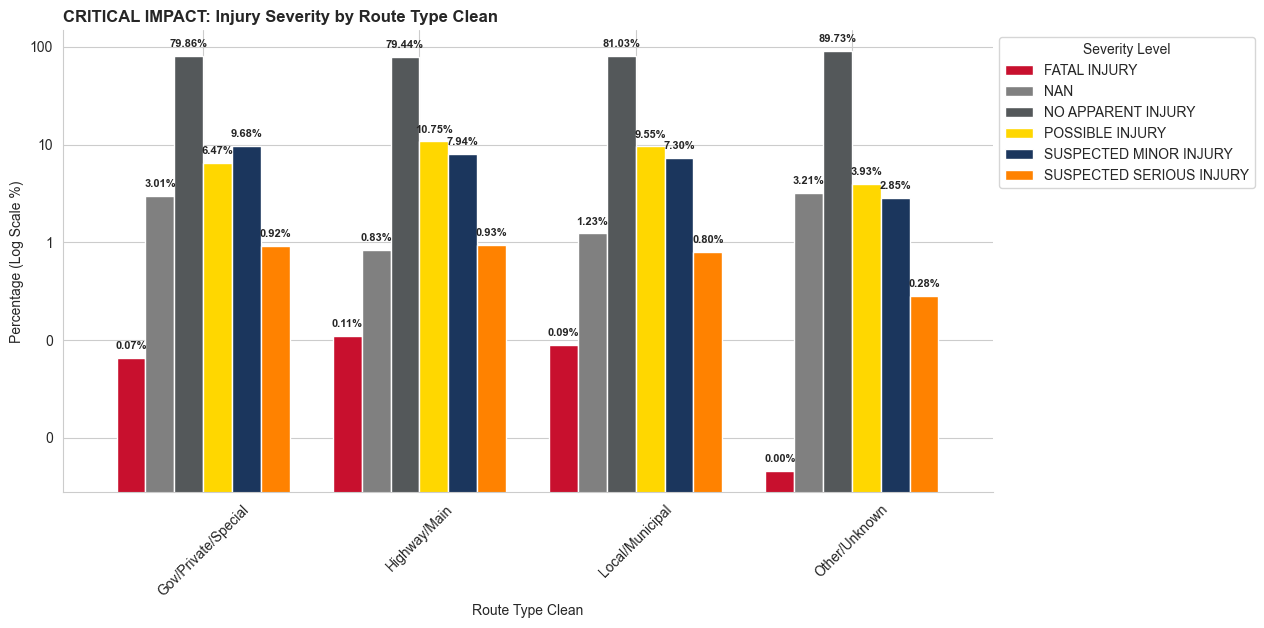


————————————————————————————————————————————————————————————

ANALYST INSIGHTS:

Patterns of crash severity are similar for all route types, although slightly higher proportions of possible and serious injuries occur 
 on highways and main roads compared with local roads. This indicates that higher speeds and volumes on highways and main roads increase 
 the risk of injury, while local roads have lower severity outcomes.



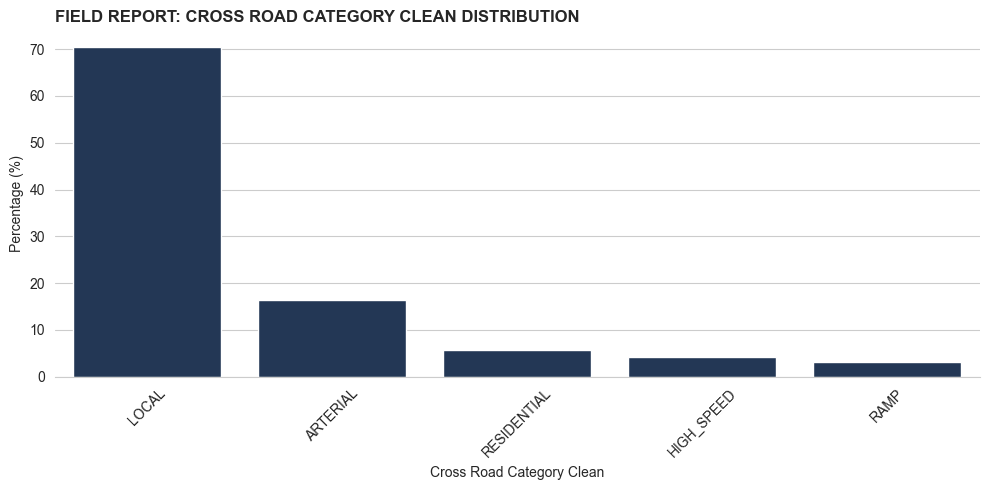


————————————————————————————————————————————————————————————


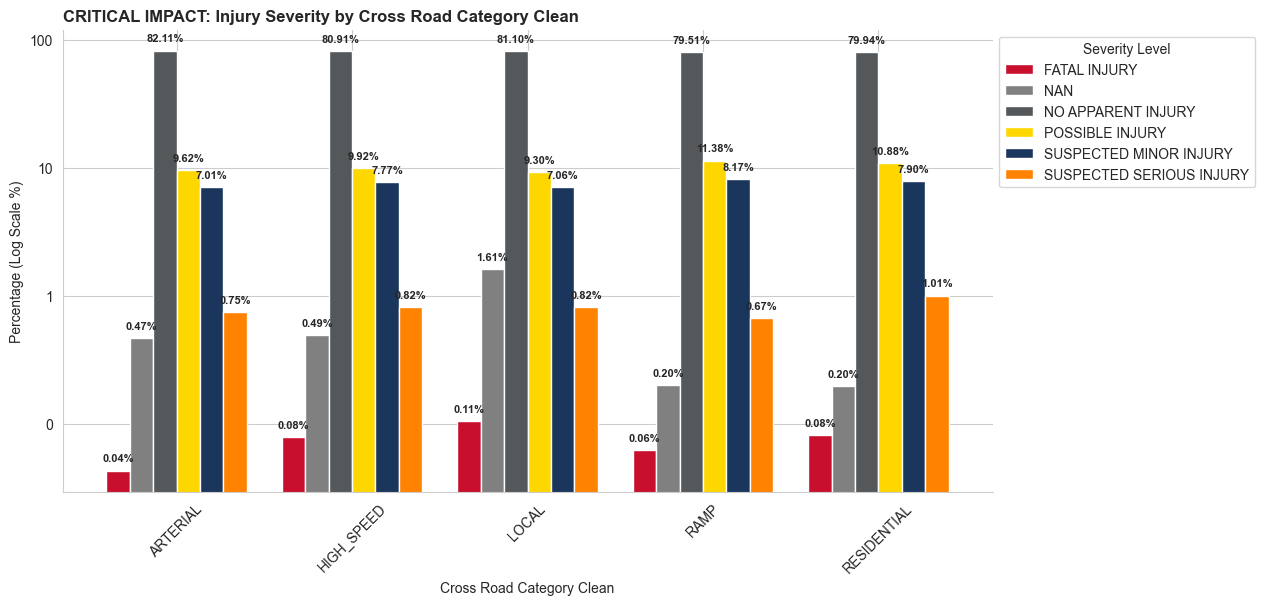


————————————————————————————————————————————————————————————

ANALYST INSIGHTS:

High-speed and ramp intersections have relatively higher proportions of injuries than arterial and local cross roads, which shows that 
   the merging conflicts, turning movements, and speed differences at these points tend to increase the severity of the crash.



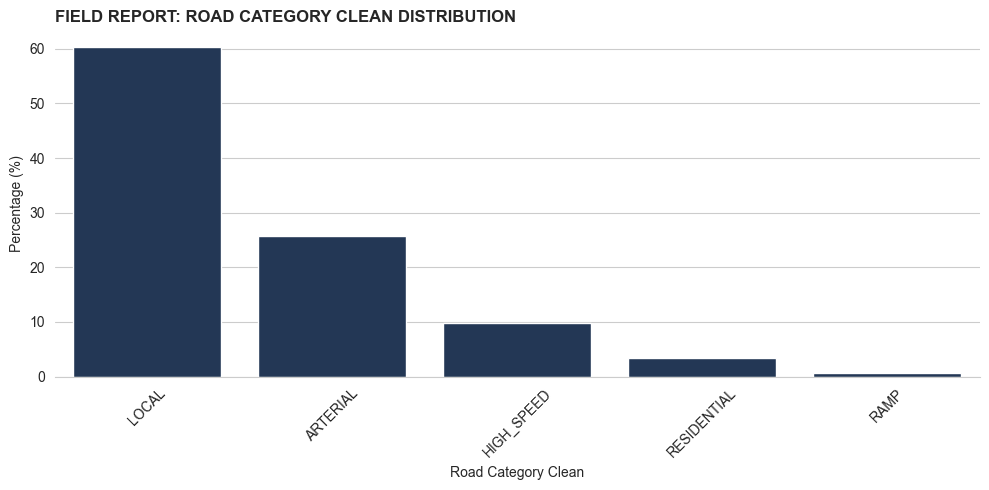


————————————————————————————————————————————————————————————


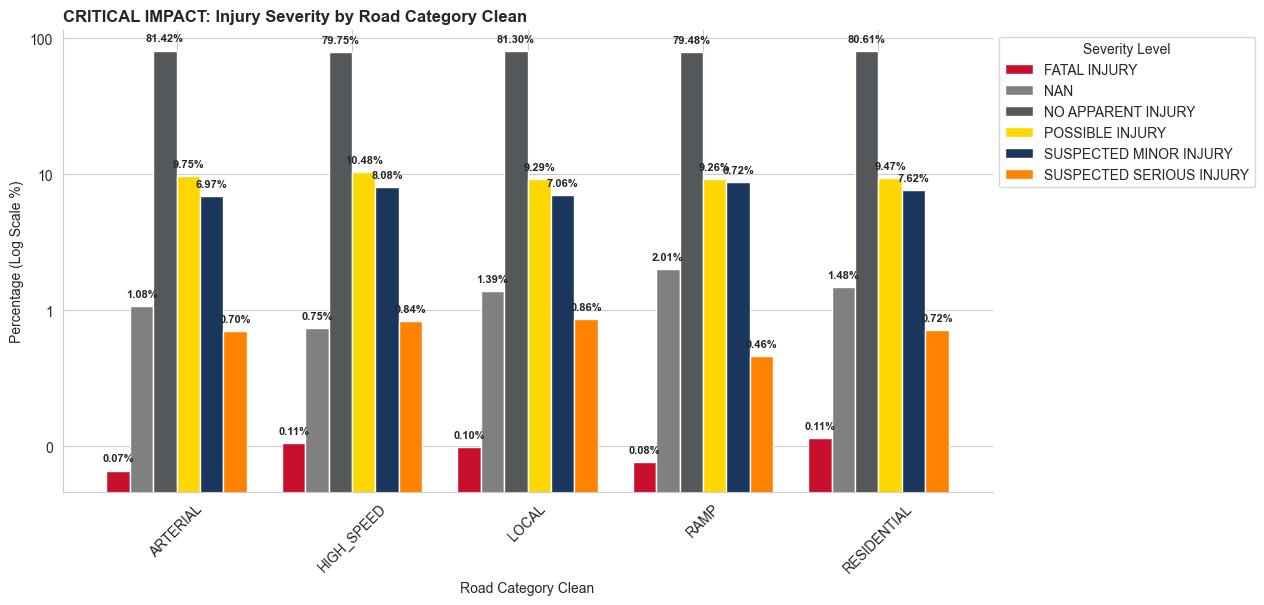


————————————————————————————————————————————————————————————

ANALYST INSIGHTS:

The High speed roads always demonstrate higher possible and serious injury percentages than local or arterial roads. This further 
 supports the strong relationship between road hierarchy, travel speed, and injury severity.



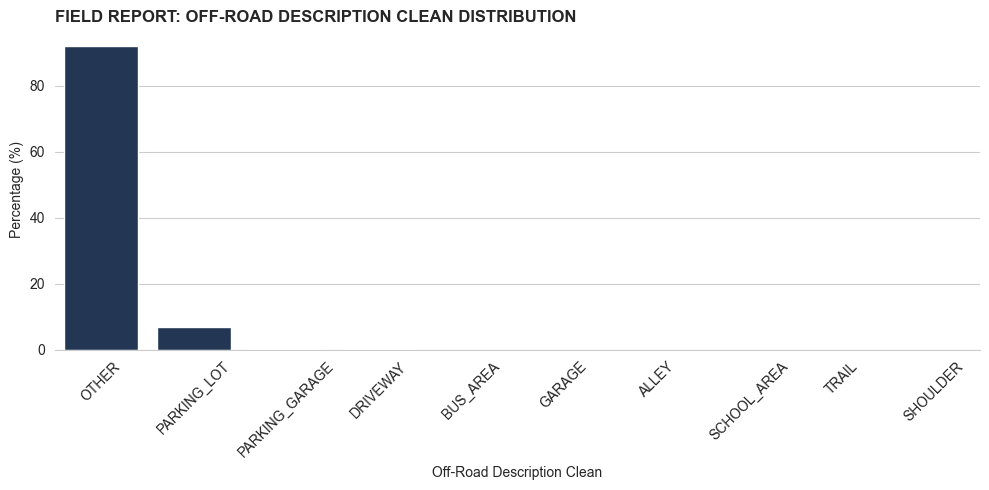


————————————————————————————————————————————————————————————


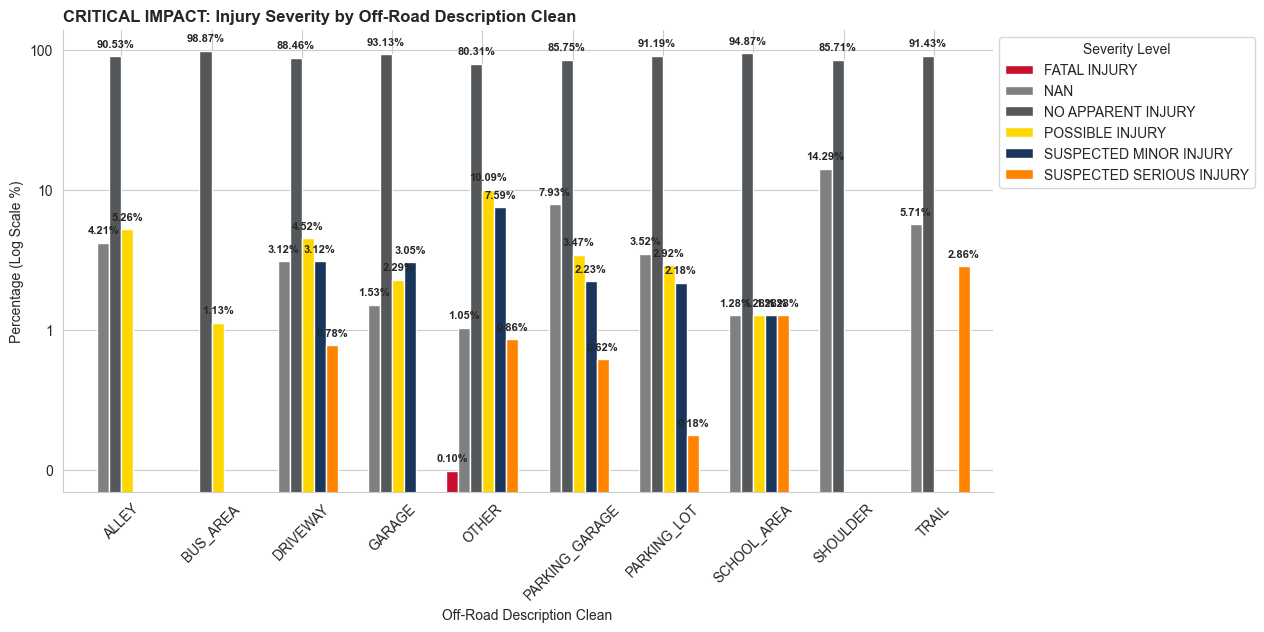


————————————————————————————————————————————————————————————

ANALYST INSIGHTS:

Off-road areas like parking lots, alleys, and driveways have a remarkably low level of injury severity. This is mainly because   there 
 are lower speeds and fewer traffic conflicts in these areas



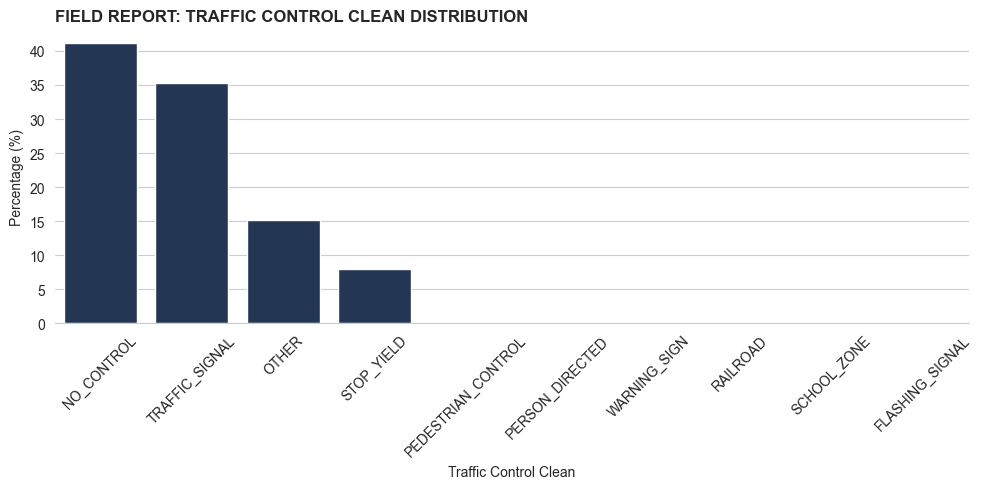


————————————————————————————————————————————————————————————


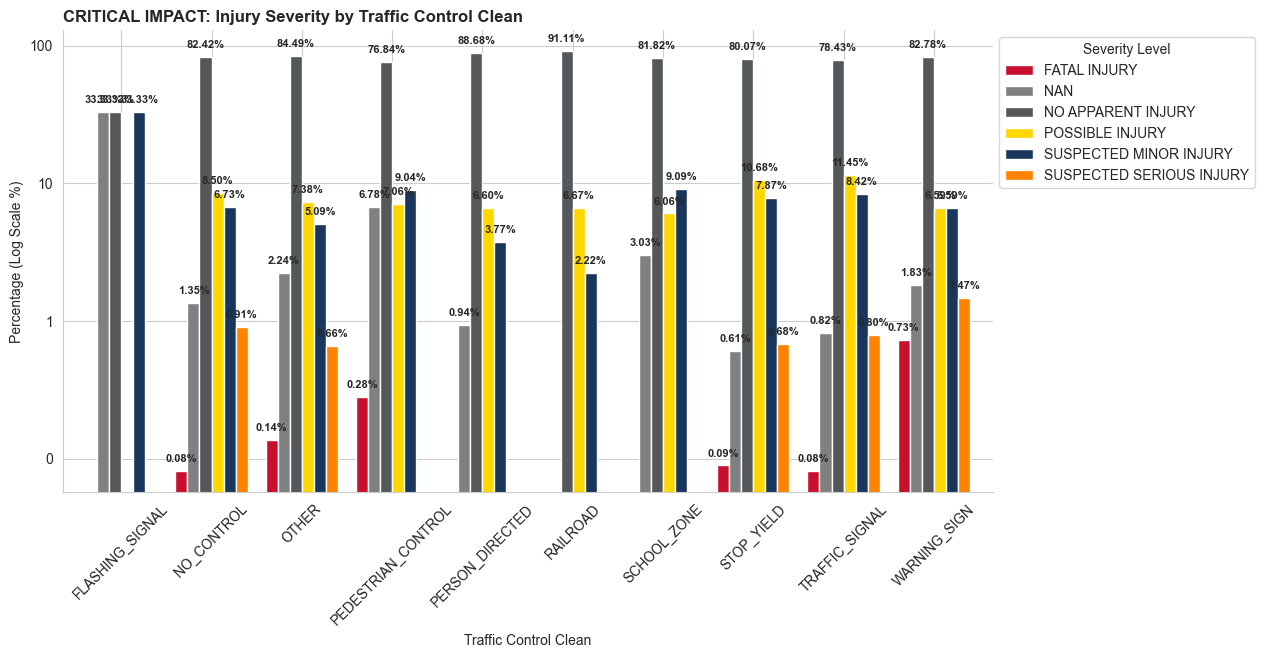


————————————————————————————————————————————————————————————

ANALYST INSIGHTS:

Areas that lack traffic control or have complex signal systems are likely to have a higher proportion of injuries than controlled 
 areas.   Stop signs, signals, and directed traffic are traffic control devices that can reduce the risk of severe injury by controlling traffic flow.



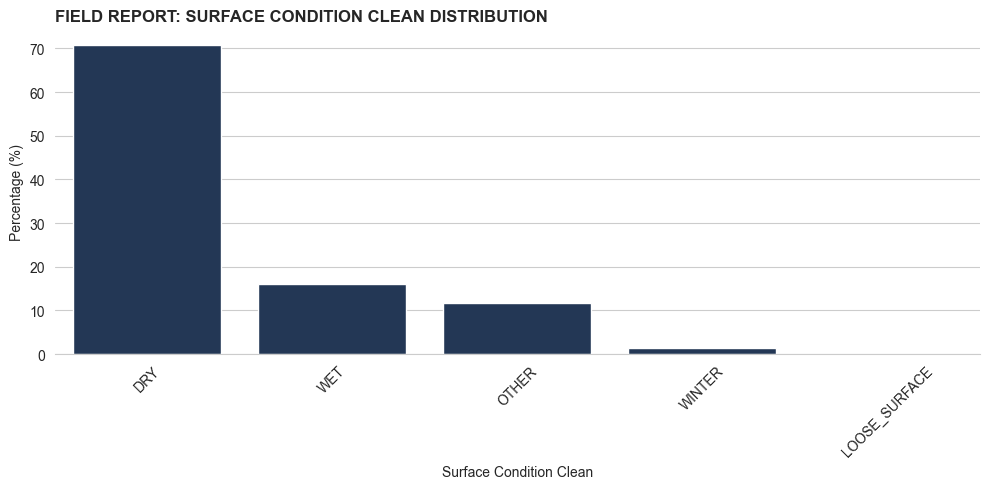


————————————————————————————————————————————————————————————


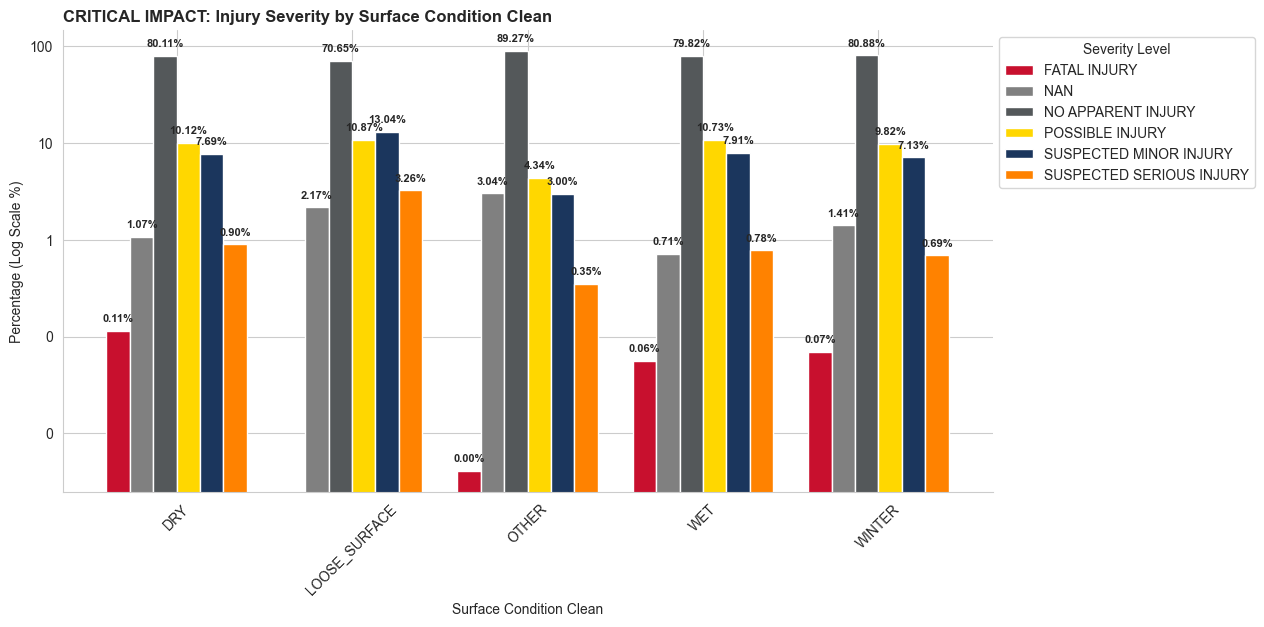


————————————————————————————————————————————————————————————

ANALYST INSIGHTS:

Loose or unstable road surfaces have a significantly higher percentage of minor and serious injuries compared to other road surfaces. 
  Dry and wet road surfaces have similar distributions of severity, suggesting that extreme road conditions are more hazardous than weather 
 conditions.



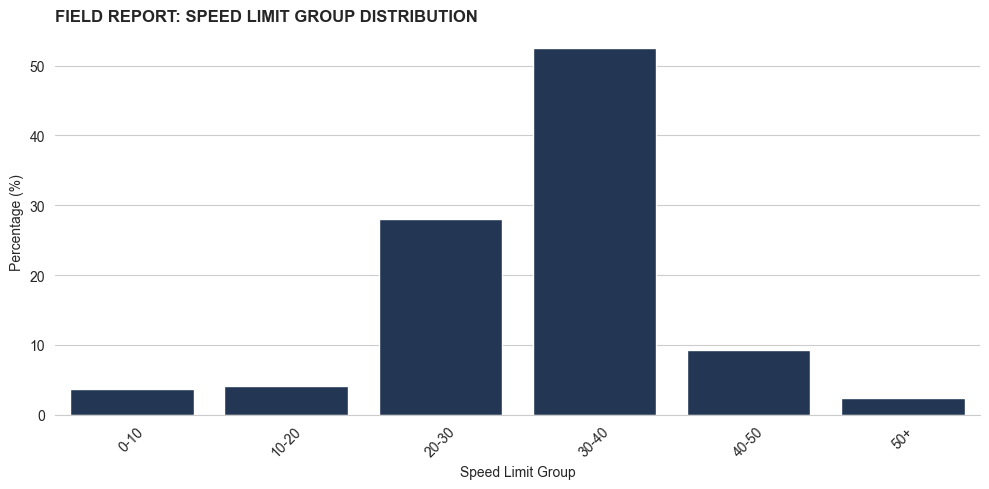


————————————————————————————————————————————————————————————


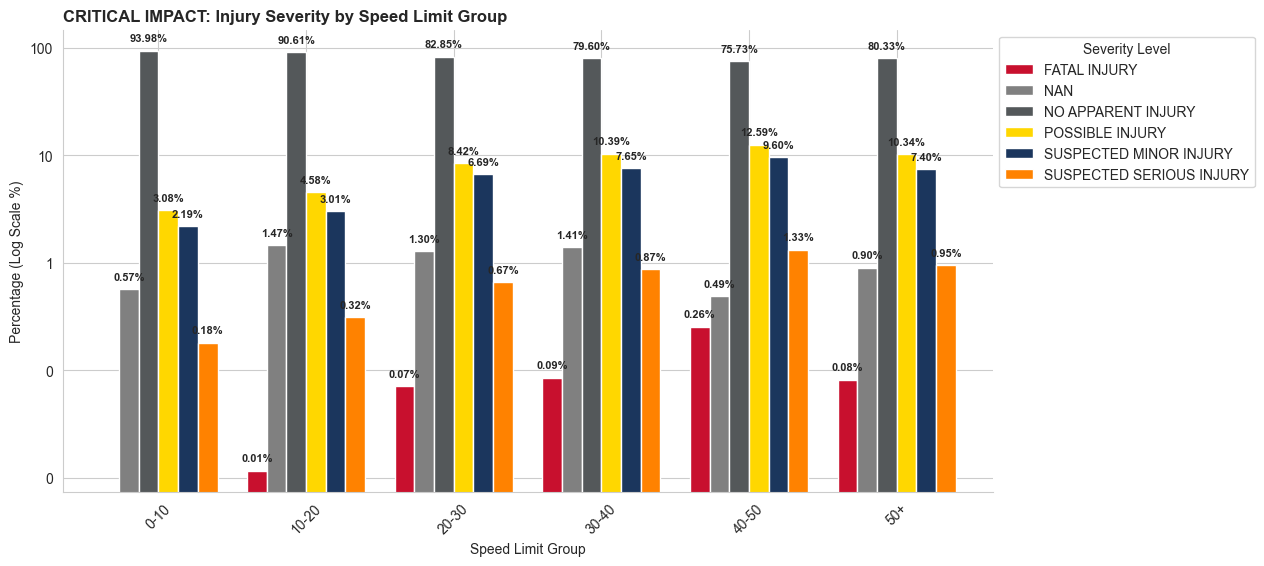


————————————————————————————————————————————————————————————

ANALYST INSIGHTS:

The severity of injury rises steadily with increasing speed limits. Zones with higher speed limits (particularly above 40 mph) 
 demonstrate evident rises in   possible, minor, and serious injuries, proving speed to be a very strong predictor of crash severity.



In [ ]:
for col in Road_related_factors:
    get_feature_insights(feature=col, explanation=road_factor_insights[col])

##### - Analysis of road-related factors shows that road environment, design, and conditions have a significant effect on injury severity. High-speed roads like highways, arterial roads, and roads with higher speed limits have a noticeable increase in possible, minor, and serious injuries compared to local or municipal roads, which emphasizes the effect of vehicle speed on crash severity. Intersections and ramps also have a tendency to have higher injury proportions because of complex traffic movements. 
##### - Road surface conditions are also significant, as loose or unstable road surfaces have a noticeable increase in serious injury rates, which may be due to the effect of reduced vehicle control and stopping distances. 
##### - On the other hand, off-road sites like parking lots, alleys, and driveways have an overwhelmingly low injury severity because the crashes that occur in these sites are at very low speeds.
##### - The effect of traffic control measures on safety is further supported by the fact that controlled intersections (signals, stop signs, and pedestrian control) tend to have lower proportions of severe injury than those without control. 
##### - Lastly, the analysis of speed limit data clearly illustrates that the severity of injury increases steadily with increasing speed limits, thus reiterating the fact that speed is a fundamental predictor of crash outcomes. 
##### - In summary, the above results collectively indicate that road geometry, traffic management infrastructure, road surface, and speed conditions are critical factors that influence the severity of accidents and, therefore, should be central to road safety strategies.

## Environmental Factors

In [ ]:
Environmental_features = [
    "Weather Clean",
    "Light Clean",
    "Surface Condition Clean"
]

environmental_factor_insights = {

"Weather Clean":
"The data for weather conditions indicates that there is relatively small variation in the severity of injury, but reduced visibility \n conditions such as dust and fog have a significantly higher proportion of possible and minor injuries. This indicates that the impairment \n of visibility has a more significant effect on the severity of crashes than weather conditions such as rain and cloudy conditions.",


"Light Clean":
"Lighting conditions are major factors that affect the severity of a crash. Dark, unlighted conditions have the highest proportion of \n fatal and serious injury crashes, which shows that the lack of visibility and the reduced time drivers have to react to a situation at \n night make the severity of a crash more likely than during the daytime.",


"Surface Condition Clean":
"The condition of the road surface is a very significant factor in injury severity. Loose and unstable road surfaces have a significantly \n higher rate of minor and serious injuries compared to the other road surface conditions. However, dry and normal wet road surfaces have \n similar injury severity patterns, which suggest that severe road surface instability has a greater impact on severe injury outcomes than adverse weather conditions."
}

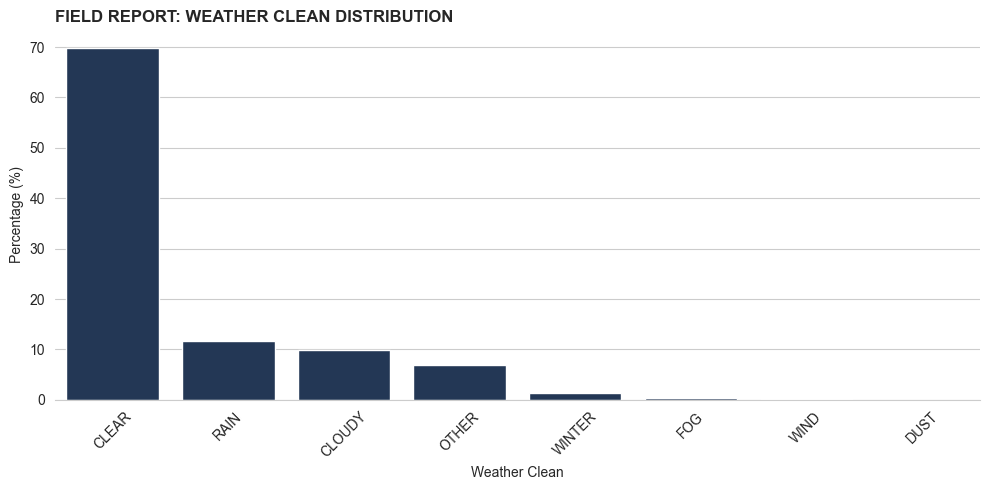


————————————————————————————————————————————————————————————


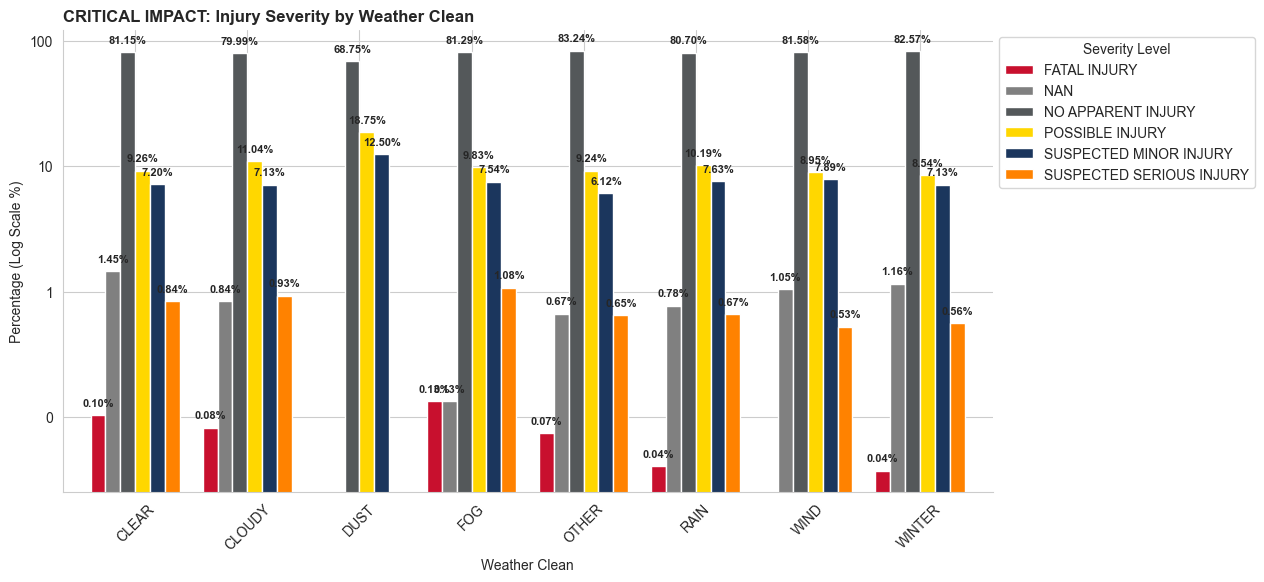


————————————————————————————————————————————————————————————

ANALYST INSIGHTS:

The data for weather conditions indicates that there is relatively small variation in the severity of injury, but reduced visibility 
 conditions such as dust and fog have a significantly higher proportion of possible and minor injuries. This indicates that the impairment 
 of visibility has a more significant effect on the severity of crashes than weather conditions such as rain and cloudy conditions.



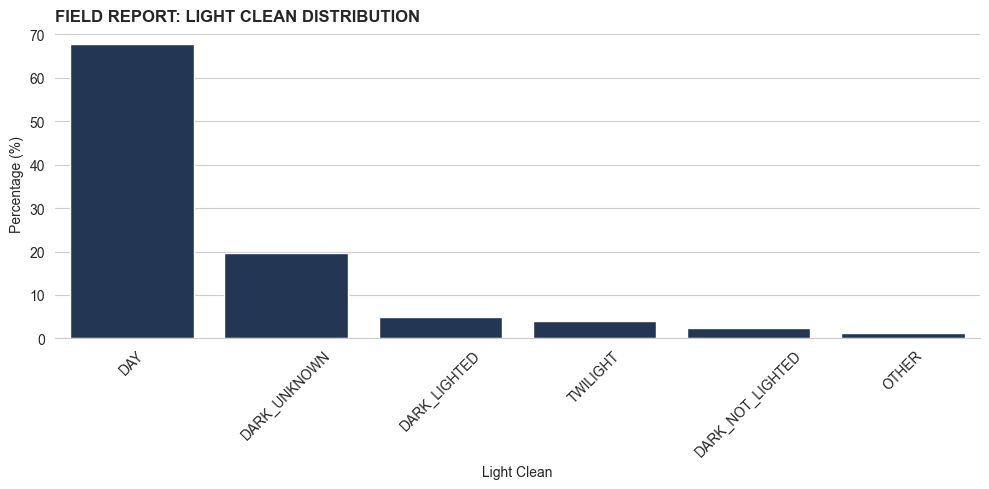


————————————————————————————————————————————————————————————


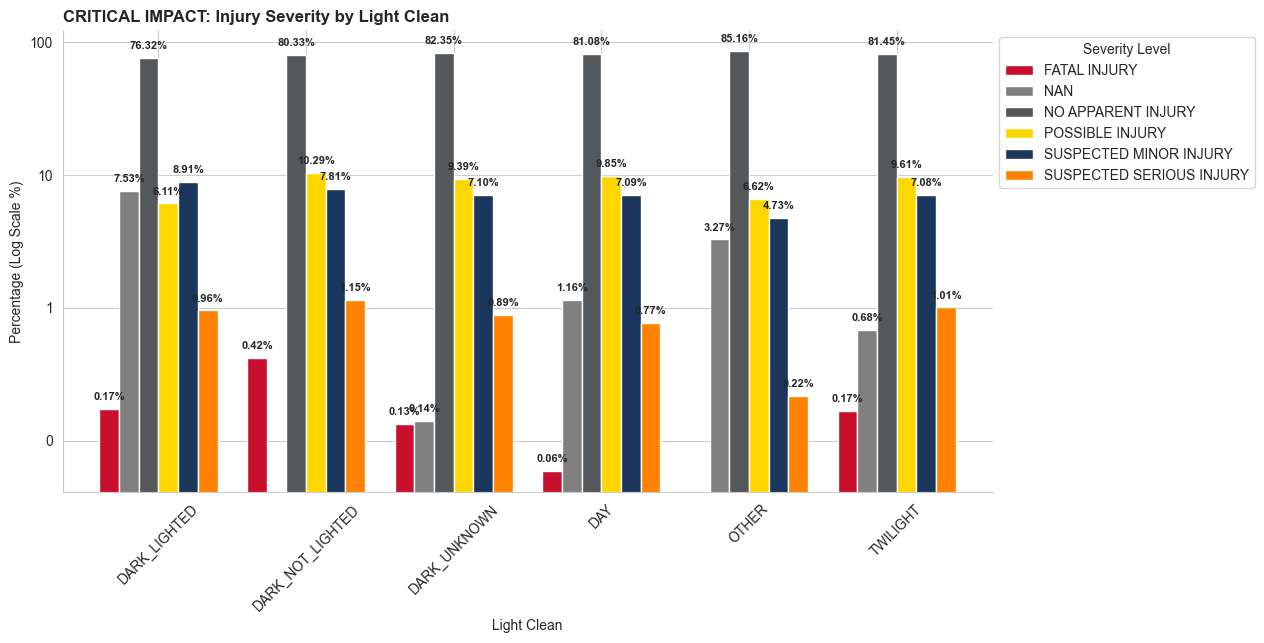


————————————————————————————————————————————————————————————

ANALYST INSIGHTS:

Lighting conditions are major factors that affect the severity of a crash. Dark, unlighted conditions have the highest proportion of 
 fatal and serious injury crashes, which shows that the lack of visibility and the reduced time drivers have to react to a situation at 
 night make the severity of a crash more likely than during the daytime.



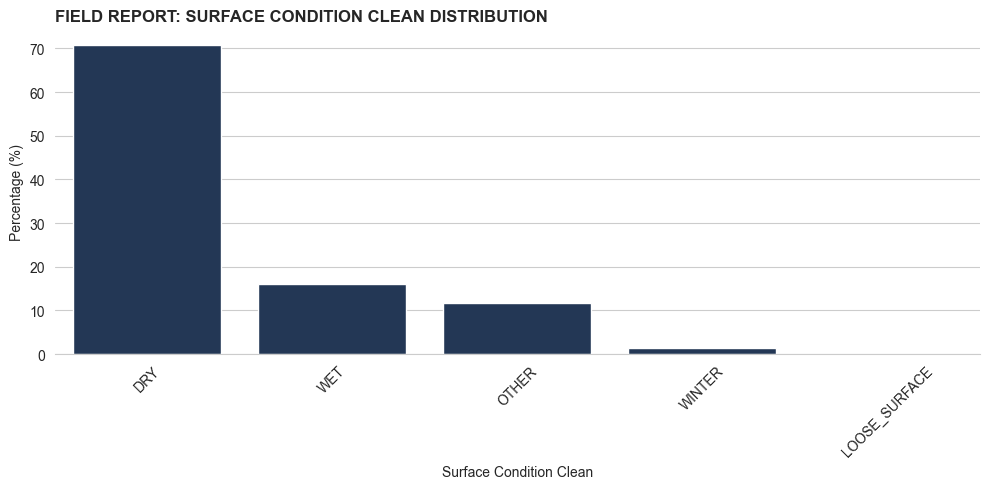


————————————————————————————————————————————————————————————


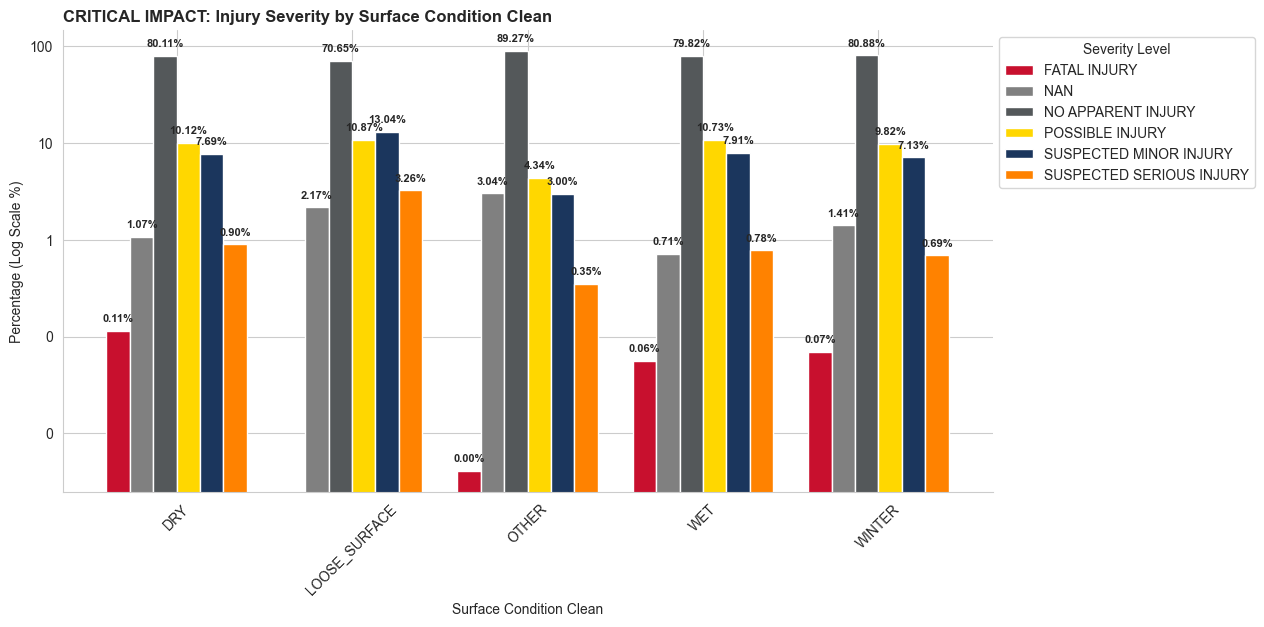


————————————————————————————————————————————————————————————

ANALYST INSIGHTS:

The condition of the road surface is a very significant factor in injury severity. Loose and unstable road surfaces have a significantly 
 higher rate of minor and serious injuries compared to the other road surface conditions. However, dry and normal wet road surfaces have 
 similar injury severity patterns, which suggest that severe road surface instability has a greater impact on severe injury outcomes than adverse weather conditions.



In [ ]:

for col in Environmental_features:
    get_feature_insights(feature=col , explanation=environmental_factor_insights[col])

##### - The condition of the road surface is a very important factor in injury severity. The loose and unstable road surface has a significantly higher rate of minor and serious injuries than the other road surface conditions. However, the dry and normal wet road surfaces have similar injury severity patterns, which indicate that the severe road surface instability has a greater effect on severe injury outcomes than the weather conditions.
##### - The condition of the road surface is a very significant factor in injury severity. The loose and unstable road surface has a significantly higher rate of minor and serious injuries than other road surface conditions. However, the dry and normal wet road surfaces have similar injury severity patterns, which indicate that the severe road surface instability has a greater impact on severe injury outcomes than weather conditions.
##### - The condition of the road surface is a very important factor in injury severity. The loose and unstable road surface has a significantly higher rate of minor and serious injuries compared to other road surface conditions. But the dry and normal wet road surfaces have similar injury severity patterns, which show that the severe road surface instability has a greater effect on severe injury outcomes than weather conditions.
##### - The condition of the road surface is a very significant factor in injury severity. The loose and unstable road surface has a significantly higher rate of minor and serious injuries than other road surface conditions. However, the dry and normal wet road surfaces have similar injury severity patterns, which indicate that the severe road surface instability has a greater impact on severe injury outcomes than weather conditions.

## Non-Motorist Factors

In [ ]:
NonMotorist_features = [
    "Related Non-Motorist Clean",
    "Non-Motorist Substance Abuse Clean"
]

non_motorist_analysis = {
  "Related Non-Motorist Clean": "This data column illustrates that the injury severity in crashes involving non-motorists is generally low, with \n the majority of incidents classified under 'No Apparent Injury'. The percentages for no injury are extremely high for all types of \n conveyances, including bicycles, pedestrians, scooters, and so on (all above 90%), which indicates that although these are vulnerable \n road users, the majority of incidents are not serious. But 'Other' and 'Multiple' non-motorists have relatively higher percentages for \n possible and minor injuries.",

  "Non-Motorist Substance Abuse Clean": "This column shows that substance use among non-motorists does not have a strong relationship with \n severe injury outcomes. The majority of categories, including alcohol and none, still display a very high percentage of 'No Apparent \n Injury.' However, the drug and medication categories display relatively higher percentages of possible injuries, which may be due to the \n impairment of reaction time, judgment, or loss of control."
}



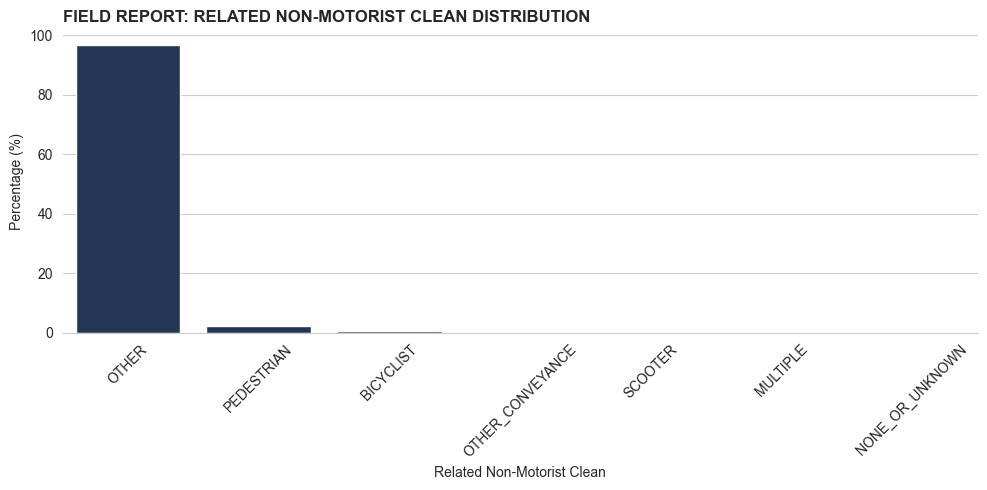


————————————————————————————————————————————————————————————


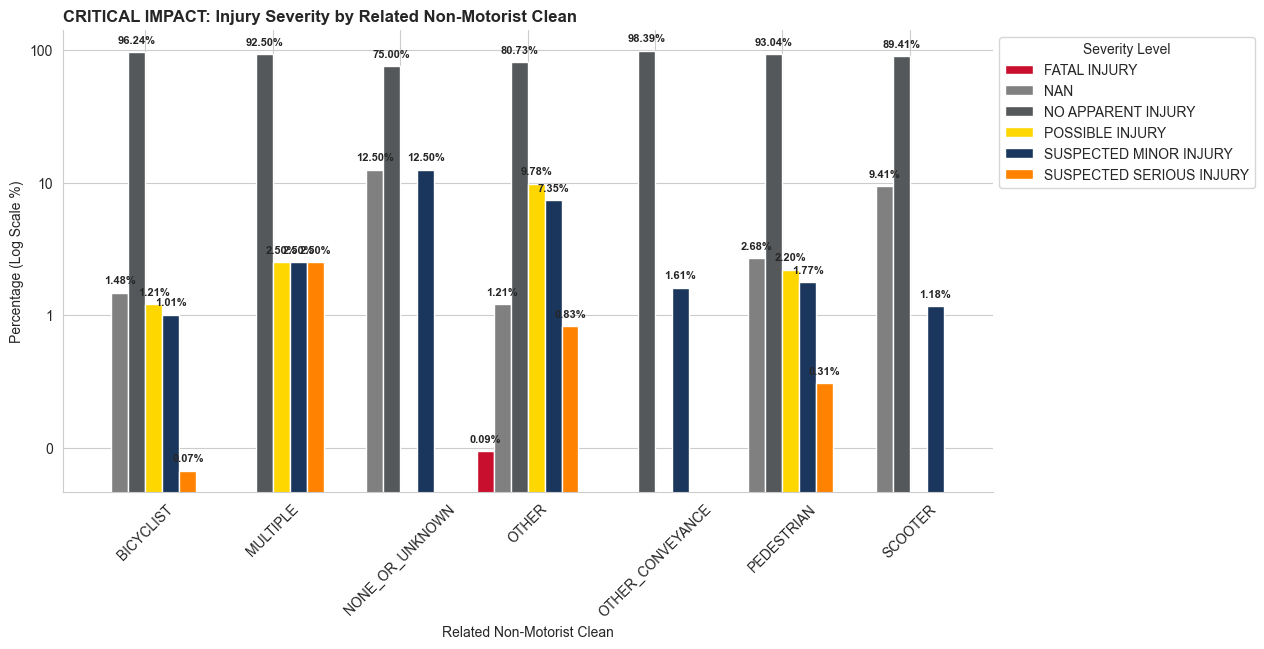


————————————————————————————————————————————————————————————

ANALYST INSIGHTS:

This data column illustrates that the injury severity in crashes involving non-motorists is generally low, with 
 the majority of incidents classified under 'No Apparent Injury'. The percentages for no injury are extremely high for all types of 
 conveyances, including bicycles, pedestrians, scooters, and so on (all above 90%), which indicates that although these are vulnerable 
 road users, the majority of incidents are not serious. But 'Other' and 'Multiple' non-motorists have relatively higher percentages for 
 possible and minor injuries.



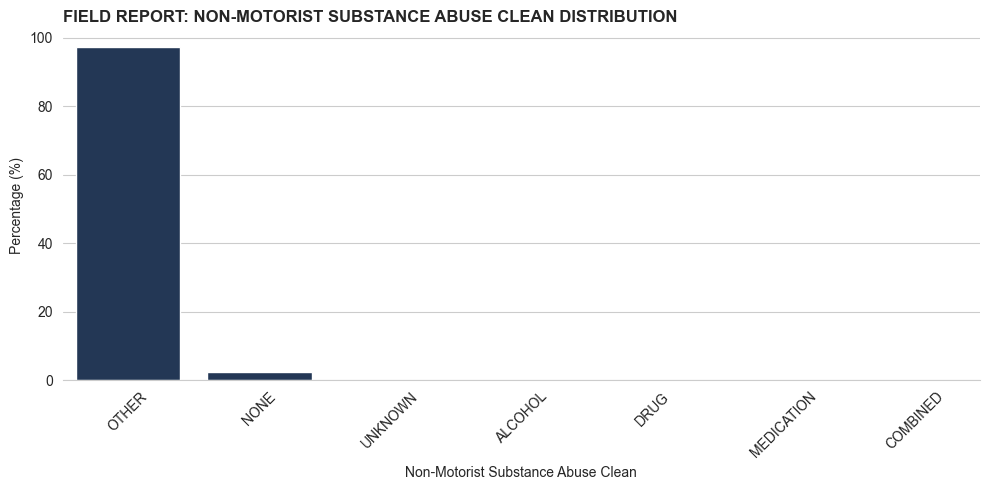


————————————————————————————————————————————————————————————


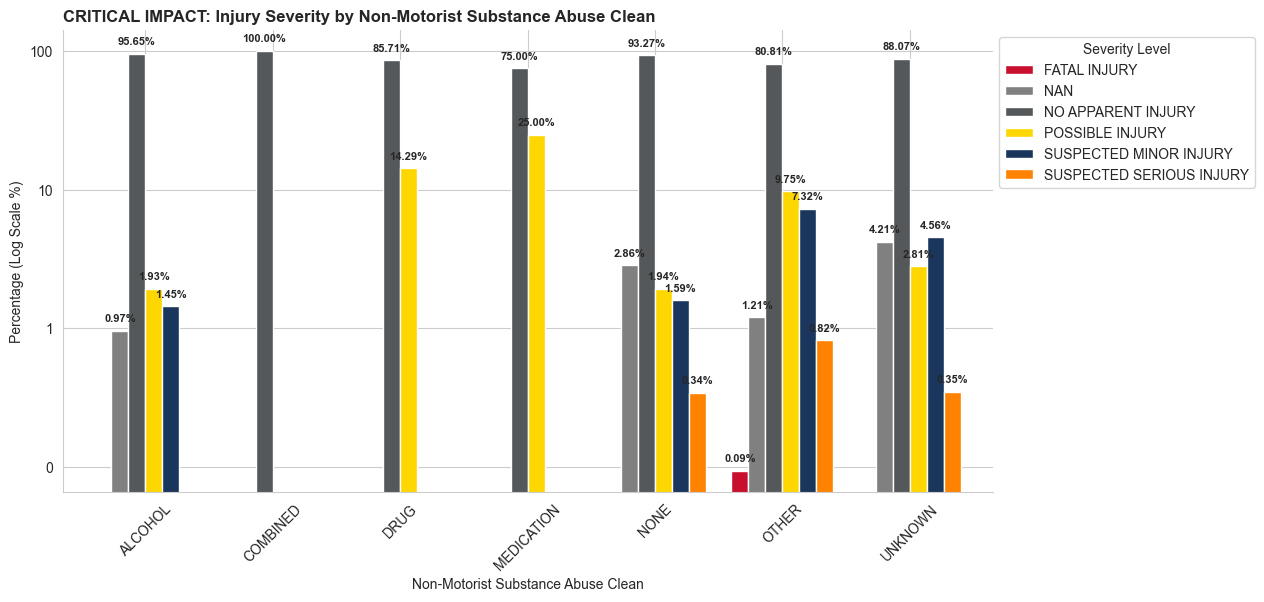


————————————————————————————————————————————————————————————

ANALYST INSIGHTS:

This column shows that substance use among non-motorists does not have a strong relationship with 
 severe injury outcomes. The majority of categories, including alcohol and none, still display a very high percentage of 'No Apparent 
 Injury.' However, the drug and medication categories display relatively higher percentages of possible injuries, which may be due to the 
 impairment of reaction time, judgment, or loss of control.



In [ ]:

for col in NonMotorist_features:
    get_feature_insights(feature=col , explanation=non_motorist_analysis[col])

##### - On the whole, the factors that are not related to non-motorists reveal that most of the accidents involving non-motorists have low injury severity, with a remarkably high proportion of accidents falling into the category of “no apparent injury.” Among the various types of non-motorists, bicyclists, pedestrians, scooters, and other vehicles have a consistently high proportion of more than 90% with no apparent injury, which clearly reveals that despite being vulnerable, most of the accidents involving these types of non-motorists are of minor severity. The “other” and “multiple non-motorist” categories have a relatively higher proportion of possible and minor injuries.
##### - Substance abuse among non-motorists does not have a strong link to severe injuries in this data set, as most categories have very high proportions of no injuries. Alcohol does not have much effect on severity, while drug and medication-related cases have relatively higher proportions of possible injuries, which may be due to impaired judgment or reaction ability. The “none” category is again dominant and follows the same pattern of low severity outcomes.

## Crash Characteristics

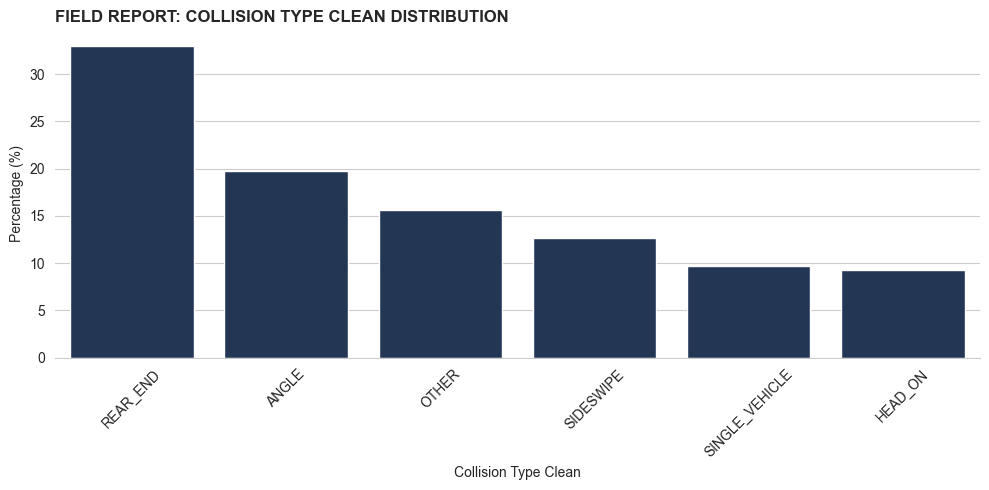


————————————————————————————————————————————————————————————


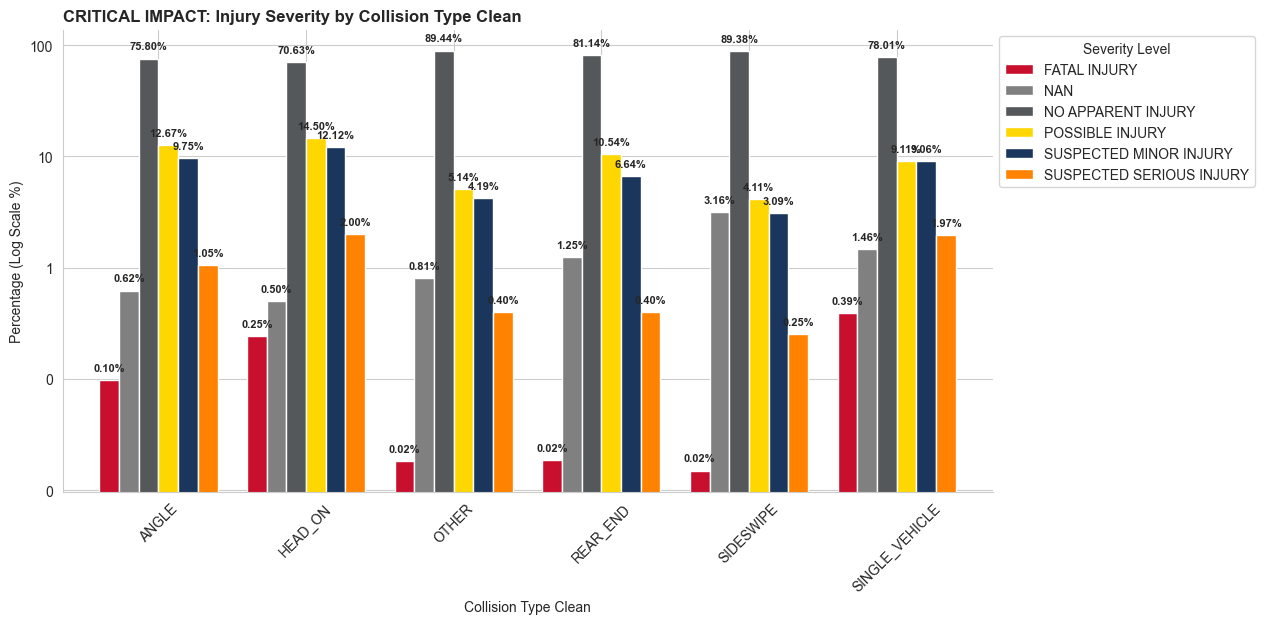


————————————————————————————————————————————————————————————

ANALYST INSIGHTS:

The type of collision is clearly linked to the level of injury severity. Head-on collisions have the greatest potential for 
 injury severity, with the greatest percentage of fatal, serious, and minor injuries, making them the most hazardous type of collision. 
 Single-vehicle collisions also have a relatively greater percentage of fatal and serious injuries, which may be attributed to the higher 
 speeds involved. Angle collisions have a moderate level of injury, which often results in possible and minor injuries. Rear-end and 
 sideswipe collisions are less severe, with a very high percentage of 'No Apparent Injury,' which may be attributed to the lower speeds 
 involved.



In [ ]:
insight = "The type of collision is clearly linked to the level of injury severity. Head-on collisions have the greatest potential for \n injury severity, with the greatest percentage of fatal, serious, and minor injuries, making them the most hazardous type of collision. \n Single-vehicle collisions also have a relatively greater percentage of fatal and serious injuries, which may be attributed to the higher \n speeds involved. Angle collisions have a moderate level of injury, which often results in possible and minor injuries. Rear-end and \n sideswipe collisions are less severe, with a very high percentage of 'No Apparent Injury,' which may be attributed to the lower speeds \n involved." 

get_feature_insights(feature="Collision Type Clean",explanation=insight)

# Location / Time Data

In [ ]:
Geo_time_features = [
    "Location Cluster Clean",
    "Time Of Day Clean",
    "Crash Dayofweek Clean",
    "Is Weekend",
    "Crash Month Clean",
    "Crash Season Clean"
]

Geo_time_Insight={
  "Location Cluster Clean" : "Nil",
  "Time Of Day Clean": "Crash severity also varies significantly by time of day. The late night and night periods have a significantly higher \n percentage of fatal and serious injury crashes than the daytime periods, primarily because of the lack of visibility, higher speeds, and \n driver fatigue. The mid-day and rush hour periods have a higher percentage of 'No Apparent Injury' crashes, which indicates that the \n crashes during heavy traffic conditions occur at a slower speed.",

  "Crash Dayofweek Clean": "Injury severity varies slightly across the week, with weekends—especially Sunday and Saturday—showing higher fatal \n and serious injury proportions compared to weekdays. This pattern may reflect increased leisure travel, nighttime driving, and possible \n risk-taking behaviors. Weekdays generally show slightly higher 'No Apparent Injury' rates, indicating relatively less severe crashes \n during routine commuting periods.",

  "Is Weekend": "Weekend crashes are slightly more severe than weekday crashes, with higher percentages of fatal, minor, and serious \n injury. While the majority of crashes are still non-injurious, the increased severity of weekend crashes indicates that speed, \n recreational driving, and possibly alcohol are contributing factors.",

  "Crash Month Clean": "Seasonal monthly patterns show that summer months like June, July, and August have higher injury severity, with \n increased possible and minor injury proportions. Winter months such as January and February have the highest 'No Apparent Injury' rates \n and lower severity, possibly due to more cautious driving behavior and slower speeds. Overall, warmer months tend to correspond with \n slightly more severe crashes.",

  "Crash Season Clean": "Crash severity varies by season, with summer showing the highest proportions of possible and minor injuries and the \n lowest 'No Apparent Injury' rates, indicating relatively more severe crashes. Winter shows the safest pattern, with the highest 'No \n Apparent Injury' share and lower severe injury levels. Spring and fall fall in between, showing moderate injury severity levels."
}



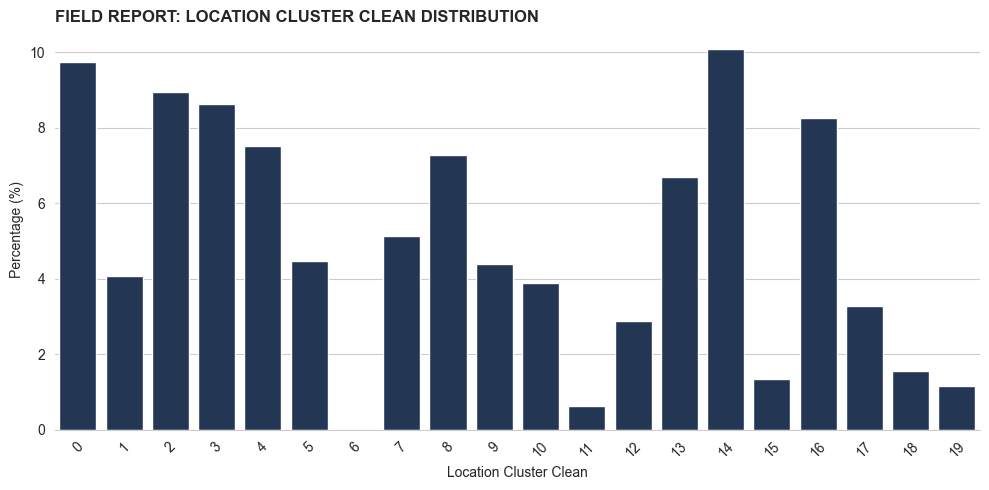


————————————————————————————————————————————————————————————


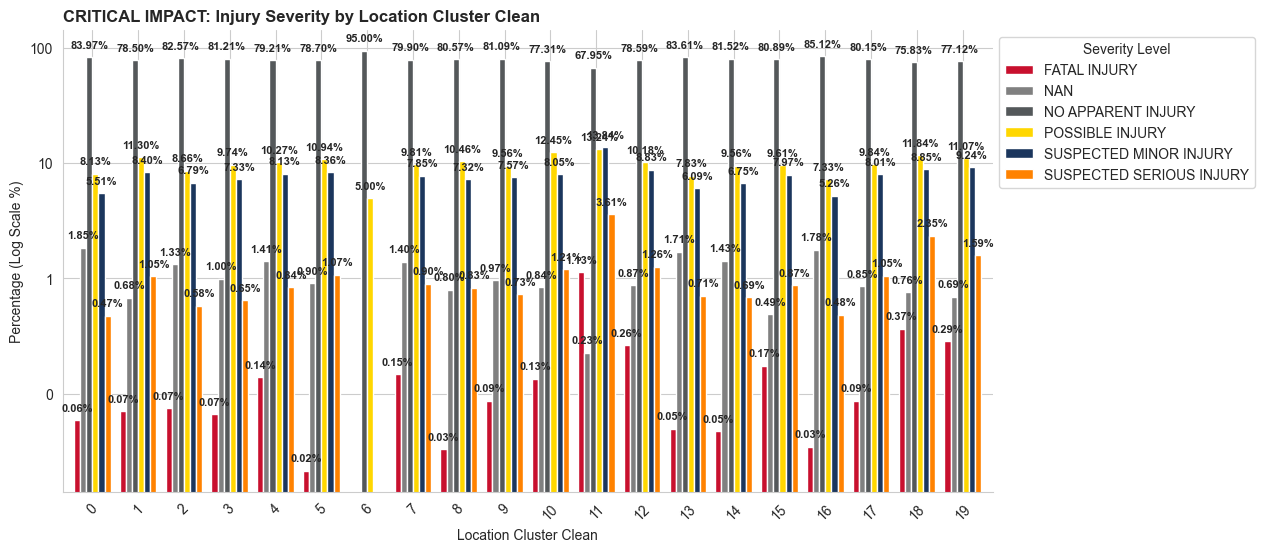


————————————————————————————————————————————————————————————

ANALYST INSIGHTS:

Nil



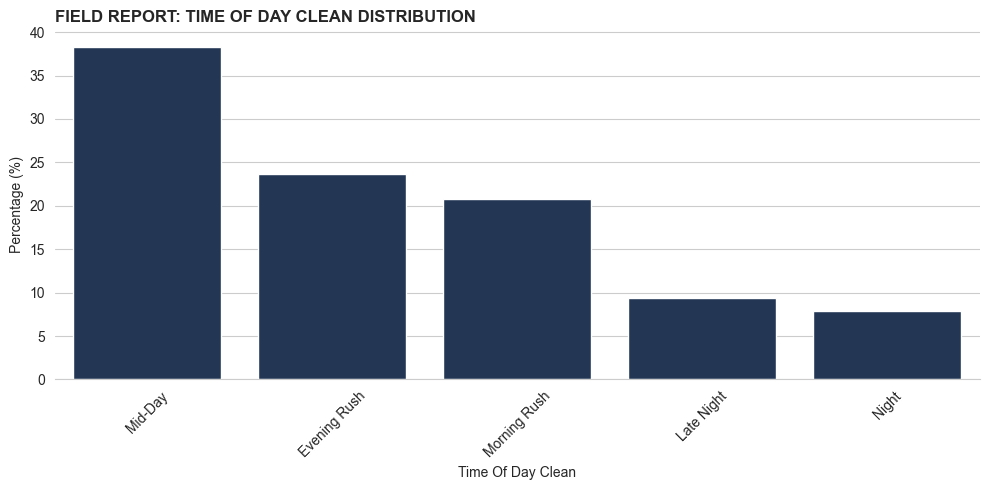


————————————————————————————————————————————————————————————


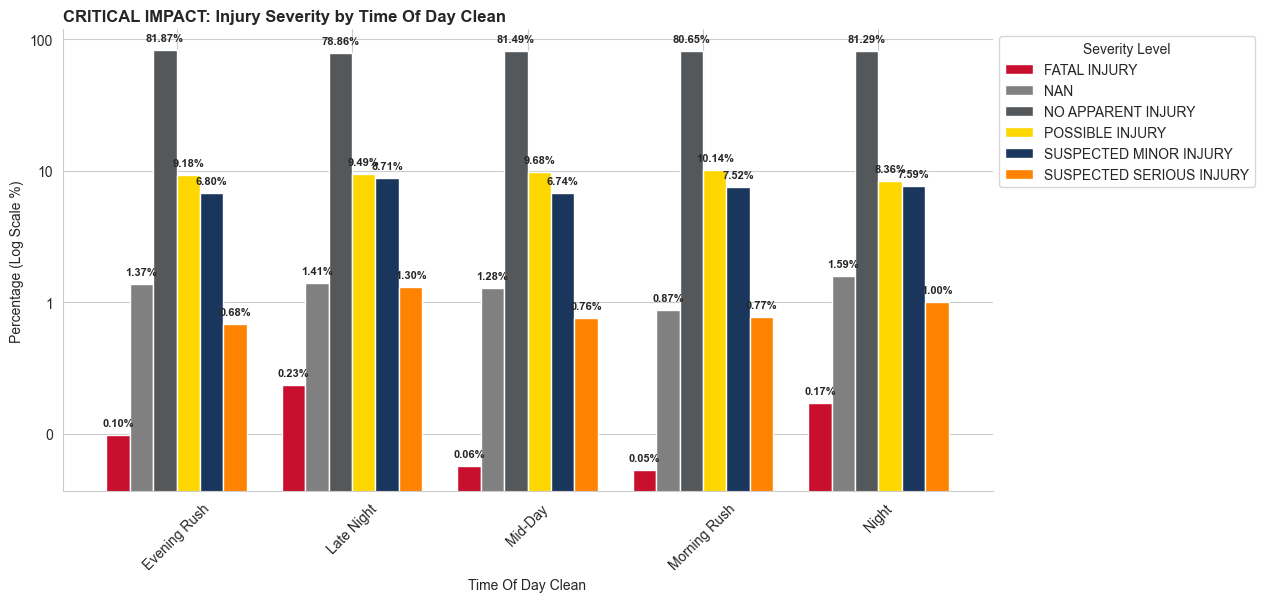


————————————————————————————————————————————————————————————

ANALYST INSIGHTS:

Crash severity also varies significantly by time of day. The late night and night periods have a significantly higher 
 percentage of fatal and serious injury crashes than the daytime periods, primarily because of the lack of visibility, higher speeds, and 
 driver fatigue. The mid-day and rush hour periods have a higher percentage of 'No Apparent Injury' crashes, which indicates that the 
 crashes during heavy traffic conditions occur at a slower speed.



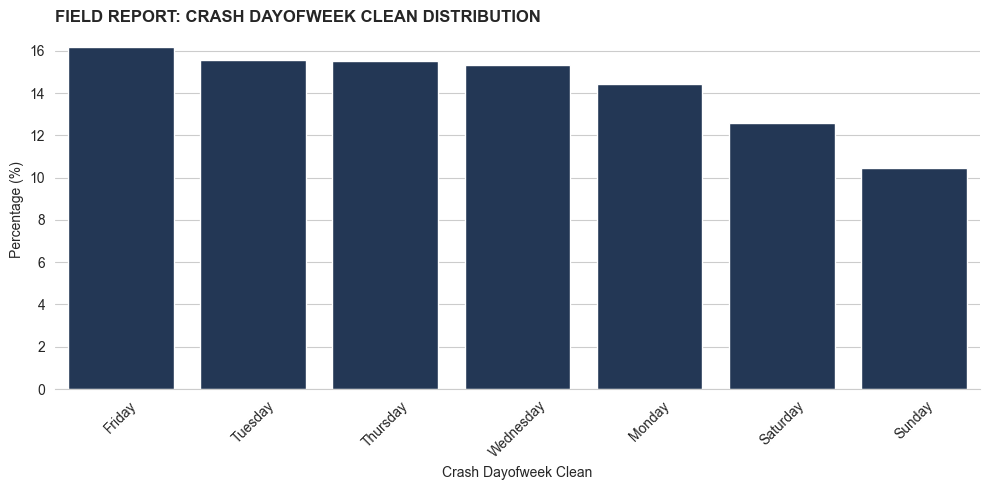


————————————————————————————————————————————————————————————


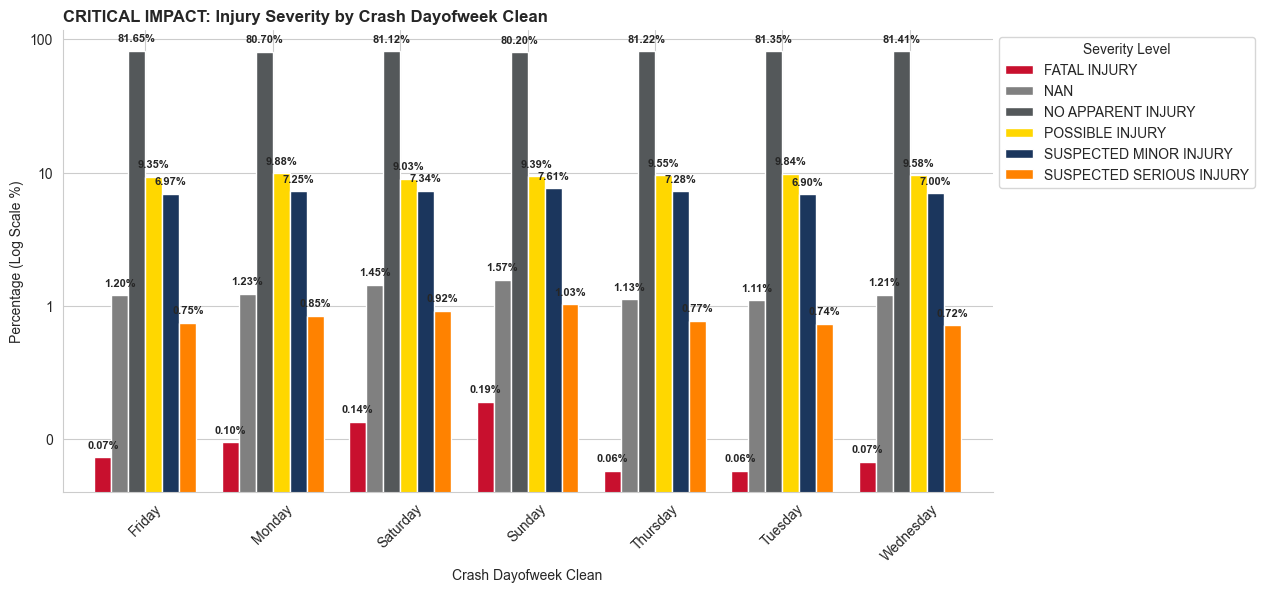


————————————————————————————————————————————————————————————

ANALYST INSIGHTS:

Injury severity varies slightly across the week, with weekends—especially Sunday and Saturday—showing higher fatal 
 and serious injury proportions compared to weekdays. This pattern may reflect increased leisure travel, nighttime driving, and possible 
 risk-taking behaviors. Weekdays generally show slightly higher 'No Apparent Injury' rates, indicating relatively less severe crashes 
 during routine commuting periods.



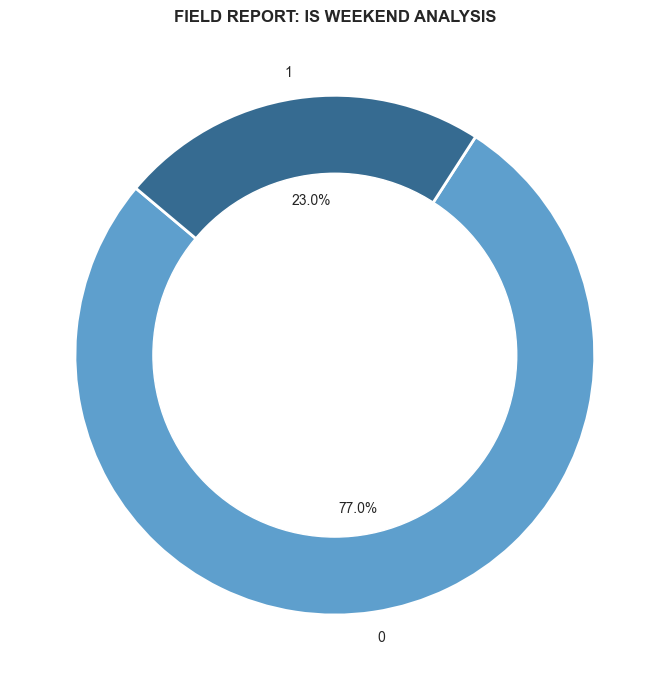


————————————————————————————————————————————————————————————


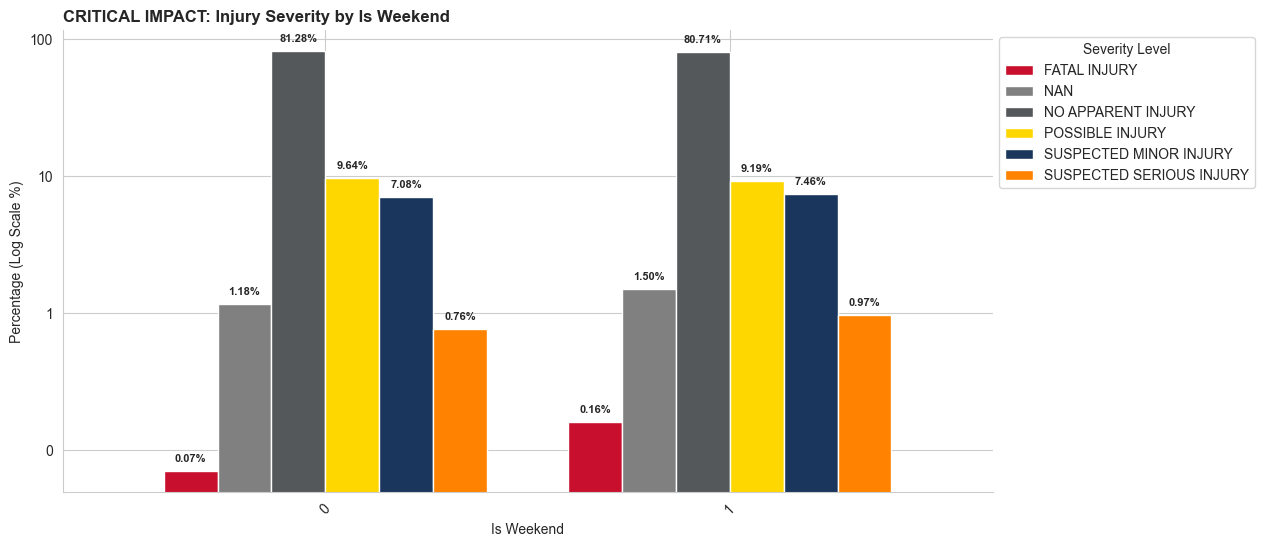


————————————————————————————————————————————————————————————

ANALYST INSIGHTS:

Weekend crashes are slightly more severe than weekday crashes, with higher percentages of fatal, minor, and serious 
 injury. While the majority of crashes are still non-injurious, the increased severity of weekend crashes indicates that speed, 
 recreational driving, and possibly alcohol are contributing factors.



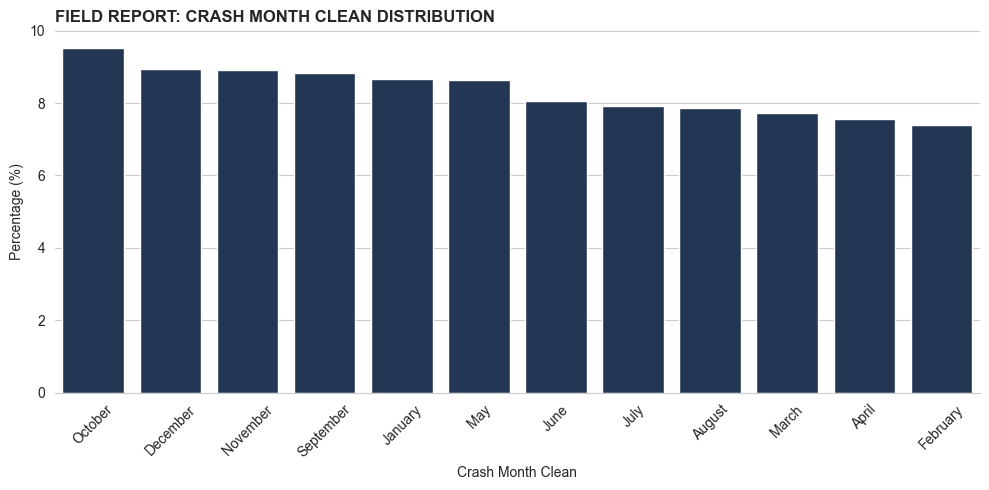


————————————————————————————————————————————————————————————


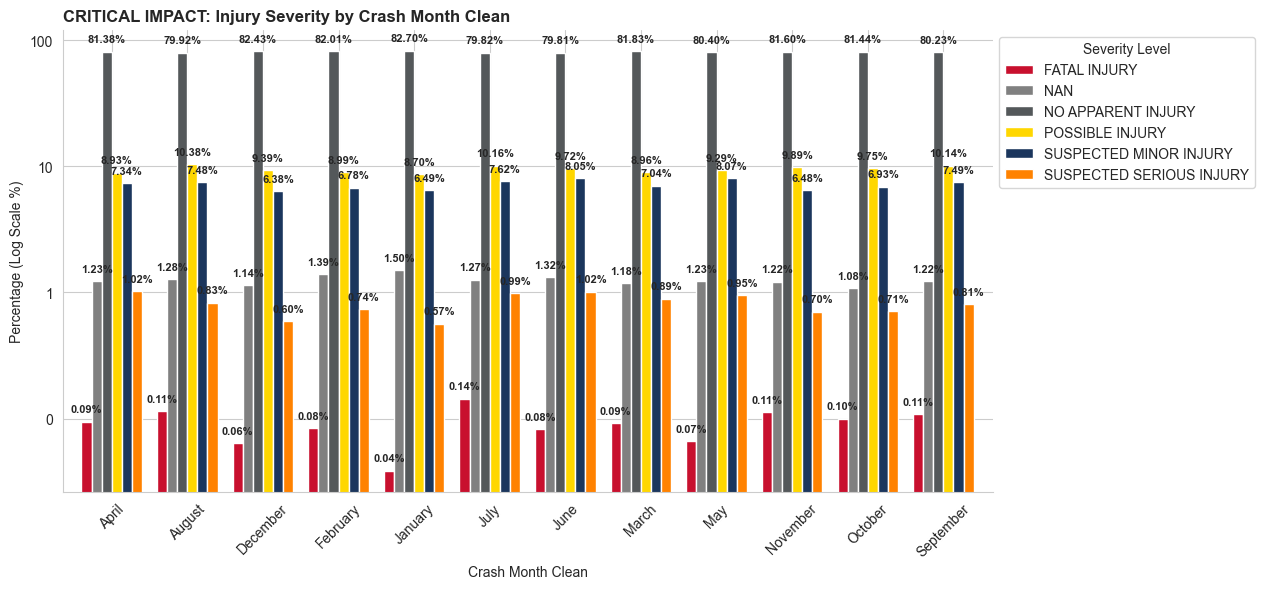


————————————————————————————————————————————————————————————

ANALYST INSIGHTS:

Seasonal monthly patterns show that summer months like June, July, and August have higher injury severity, with 
 increased possible and minor injury proportions. Winter months such as January and February have the highest 'No Apparent Injury' rates 
 and lower severity, possibly due to more cautious driving behavior and slower speeds. Overall, warmer months tend to correspond with 
 slightly more severe crashes.



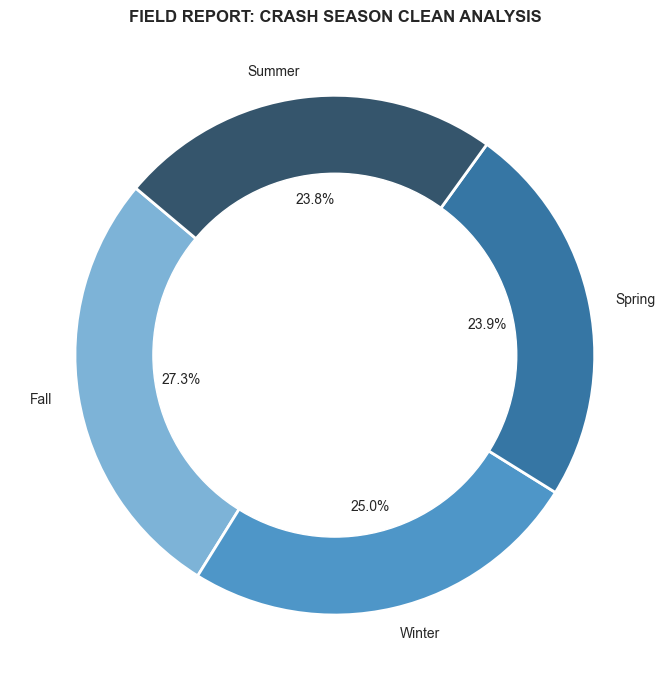


————————————————————————————————————————————————————————————


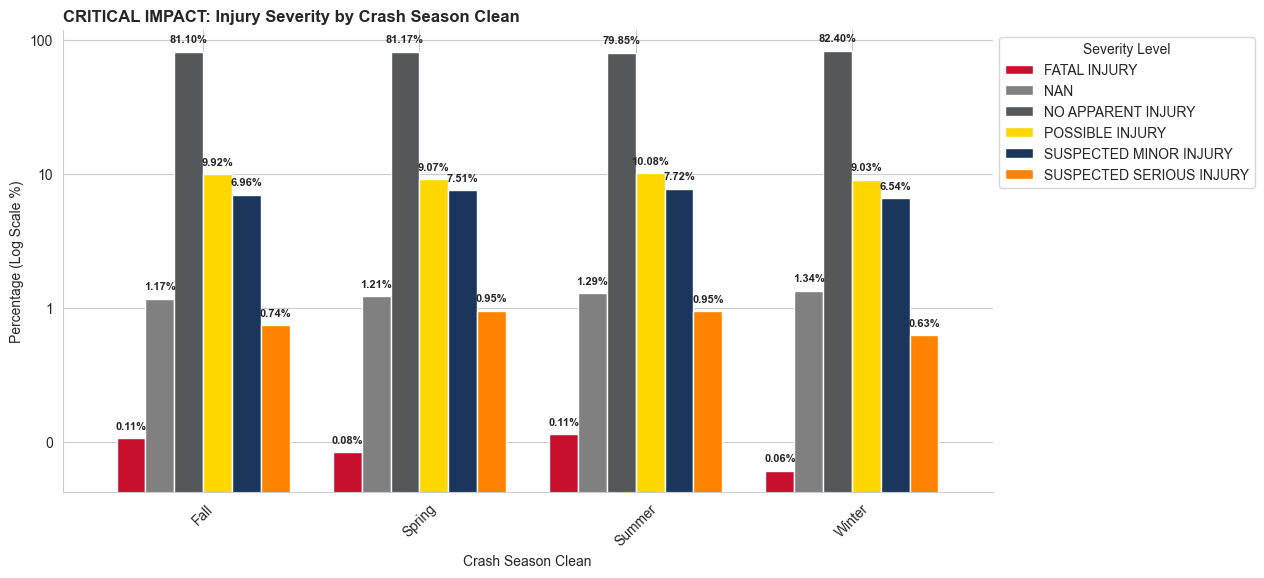


————————————————————————————————————————————————————————————

ANALYST INSIGHTS:

Crash severity varies by season, with summer showing the highest proportions of possible and minor injuries and the 
 lowest 'No Apparent Injury' rates, indicating relatively more severe crashes. Winter shows the safest pattern, with the highest 'No 
 Apparent Injury' share and lower severe injury levels. Spring and fall fall in between, showing moderate injury severity levels.



In [ ]:
for col in Geo_time_features:
    get_feature_insights(feature=col, explanation=Geo_time_Insight[col])